# SIAM Conference on Computational Science and Engineering
`CSE19` https://meetings.siam.org/program.cfm?CONFCODE=CS19<br>
`CSE23` https://meetings.siam.org/program.cfm?CONFCODE=cse23<br>
`CSE25` https://meetings.siam.org/program.cfm?CONFCODE=cse25<br>

## Initialize

In [1]:
# ==== Step 0. Install dependencise (gensim) ====
!pip install gensim
!pip install transformers sentence-transformers

In [2]:
# ==== Step 0. Download NLTK Resources ====
import nltk
nltk.download("stopwords")
nltk.download("words")
nltk.download('punkt_tab')

# ==== Step 0. Import Libraries ====
import json, nltk, string, gensim, torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from nltk import FreqDist
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

from collections import defaultdict
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, inconsistent
from scipy.spatial.distance import pdist
from sentence_transformers import SentenceTransformer
from gensim.matutils import corpus2dense
from transformers import AutoTokenizer, AutoModel

from sklearn.decomposition import PCA
from scipy.optimize import minimize_scalar

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nanatsou/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /Users/nanatsou/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nanatsou/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# ==== Step 0. Shared values  ====
def safe_join(items):
    return ' '.join(s for s in items if isinstance(s, str) and s.strip())

# ==== Step 1. Set Common High-Frequency Words (24 words) & Acronyms (31 words) ====
COMMON_WORDS = ['advanc', 'activ', 'algorithm', 'applic', 'approach', 'challeng', 'confer',
                'develop', 'discuss', 'includ', 'method', 'minisymposium', 'new', 'numer',
                'problem', 'process', 'recent', 'research', 'session', 'solut', 'solver',
                'theori', 'use', 'workshop']

ACRONYMS = [
    ('AI', 'Artificial Intelligence'), ('AMR', 'Adaptive Mesh Refinement'), ('BEM', 'Block Element Modifier'),
    ('BGCE', 'Bavarian Graduate School of Computational Engineering'), ('CFD', 'Computational Fluid Dynamics'),
    ('CSE', 'Computational Science and Engineering'), ('DSL', 'Domain Specific Language'),
    ('FD', 'Finite Difference'), ('FEM', 'Finite Element Method'), ('FFT', 'Fast Fourier Transform'),
    ('GPU', 'Graphical Processing Unit'), ('HPC', 'High Performance Computing'),
    ('LGBT', "Lesbian Gay Bisexual and Transgender"), ('LGBTQ', "Lesbian Gay Bisequal Transgender and Queer"),
    ('MHD', 'Magnetohydrodynamics'), ('MISMC', 'Multi Index Sequential Monte Carlo'),
    ('ML', 'Machine Learning'), ('MOR', 'Mathematics of Operations Research'),
    ('NICAM', 'Near Instantaneous Companded Audio Multiplex'), ('NISQ', 'Noisy Intermediate Scale Quantum'),
    ('ODE', 'Ordinary Differential Equation'), ('OED', 'Optimal Experimental Design'),
    ('PDE', 'Partial Differential Equation'), ('RBF', 'Radial Basis Function'), ('RDM', 'Research Data Management'),
    ('ROM', 'Reduced Order Modelling'), ('RSE', 'Researchers Scientists and Engineers'),
    ('SBP', 'Summation By Parts'), ('SQP', 'Sequential Quadratic Programming'),
    ('SVD', 'Singular Value Decomposition'), ('UQ', 'Uncertainty Quantification')]

## Load Data

In [4]:
# ==== Step 1. Load JSON File ====
with open("CSE19_schd.json", "r") as f:
    cse19_schd = json.load(f)

with open("CSE23_schd.json", "r") as f:
    cse23_schd = json.load(f)

with open("CSE25_schd.json", "r") as f:
    cse25_schd = json.load(f)

def get_rooms(schd):
  rooms = set()
  for session_id, session in schd.items():
      if "talks" in session and session["talks"]:
          rooms.add(session.get("room"))
  return len(rooms)

cse19_rooms = get_rooms(cse19_schd)
cse23_rooms = get_rooms(cse23_schd)
cse25_rooms = get_rooms(cse25_schd)

print(f"CSE19: {cse19_rooms} rooms")
print(f"CSE23: {cse23_rooms} rooms")
print(f"CSE25: {cse25_rooms} rooms")

# ==== Step 2. Load Models ====
cse19_tfidf = gensim.similarities.MatrixSimilarity.load("4_CSE19_tfidf_sims.data")
cse23_tfidf = gensim.similarities.MatrixSimilarity.load("4_CSE23_tfidf_sims.data")
cse25_tfidf = gensim.similarities.MatrixSimilarity.load("4_CSE25_tfidf_sims.data")


cse19_sbert_embeddings = np.load("4_CSE19_sbert_embeddings.npy")
cse23_sbert_embeddings = np.load("4_CSE23_sbert_embeddings.npy")
cse25_sbert_embeddings = np.load("4_CSE25_sbert_embeddings.npy")


cse19_specter_embeddings = np.load("4_CSE19_specter_embeddings.npy")
cse23_specter_embeddings = np.load("4_CSE23_specter_embeddings.npy")
cse25_specter_embeddings = np.load("4_CSE25_specter_embeddings.npy")

# ==== Step 3. The number of MS ====
print(f"CSE19_tfidf: {len(cse19_tfidf)}")
print(f"CSE23_tfidf: {len(cse23_tfidf)}")
print(f"CSE25_tfidf: {len(cse25_tfidf)}")

print(f"CSE19_sbert_embeddings: {len(cse19_sbert_embeddings)}")
print(f"CSE23_sbert_embeddings: {len(cse23_sbert_embeddings)}")
print(f"CSE25_sbert_embeddings: {len(cse25_sbert_embeddings)}")

print(f"CSE19_specter_embeddings: {len(cse19_specter_embeddings)}")
print(f"CSE23_specter_embeddings: {len(cse23_specter_embeddings)}")
print(f"CSE25_specter_embeddings: {len(cse25_specter_embeddings)}")

CSE19: 38 rooms
CSE23: 37 rooms
CSE25: 32 rooms
CSE19_tfidf: 421
CSE23_tfidf: 417
CSE25_tfidf: 319
CSE19_sbert_embeddings: 421
CSE23_sbert_embeddings: 417
CSE25_sbert_embeddings: 319
CSE19_specter_embeddings: 421
CSE23_specter_embeddings: 417
CSE25_specter_embeddings: 319


In [5]:
# Initialize for each YEAR

## CSE19
#conference_prefix = "CSE19_"
#sims = cse19_tfidf
#NCLUSTERS = cse19_rooms
#schd = cse19_schd

#sbert_embeddings = cse19_sbert_embeddings
#rooms = cse19_rooms

#specter_embeddings = cse19_specter_embeddings

## CSE23
conference_prefix = "CSE23_"
sims = cse23_tfidf
NCLUSTERS = cse23_rooms
schd = cse23_schd

sbert_embeddings = cse23_sbert_embeddings
rooms = cse23_rooms

specter_embeddings = cse23_specter_embeddings


## CSE25
#conference_prefix = "CSE25_"
#sims = cse25_tfidf
#NCLUSTERS = cse25_rooms
#schd = cse25_schd

#sbert_embeddings = cse25_sbert_embeddings
#rooms = cse25_rooms

#specter_embeddings = cse25_specter_embeddings

## Stage 3: Clutsering

## A1: TFIDF + KMenas (k = rooms)

In [6]:
# ==== Step 1. KEY CHANGES: TF-IDF embeddings normalization (cosine clustering) ====
normalized_tfidf = normalize(np.array(sims.index), norm = "l2") #for A1, A2 & A2

# ==== Step 2. K-means Clustering ====

# KEY CHANGES:
# 1. The original script printed the clustering results and stored the predicted keywords in "mini_list" without a structured format
# 2. Restructure the clustering output: theme_id, tiltle and top 5 keywords, into a list of dictionaries (cluster_results)
# 3. Set a random state to fix the result


# Use k-means to cluster the data
kmeans = KMeans(n_clusters = NCLUSTERS, random_state = 123, n_init = 10).fit(normalized_tfidf)
labels_A1 = kmeans.fit_predict(normalized_tfidf)

# Set Stop words
stop_words = set(stopwords.words("english") + COMMON_WORDS)

# Create the stemmer
stemmer = PorterStemmer()

# ==== Step 3. KEY CHANGES - Simulate the Original minisymposia.yaml Structure ====
mini_list = {}
for session_code, session in schd.items():
    if "talks" in session and len(session["talks"]) > 0: # ensure it's symposium
        title = session["title"] if "title" in session else ""
        abstract = session["abstract"] if "abstract" in session else ""
        talk_titles = [t["title"] for t in session["talks"] if "title" in t]
        talk_abstracts = [t["abstract"] for t in session["talks"] if "abstract" in t]

        mini_list[session_code] = {
            "title": title,
            "abstract": abstract,
            "talk_titles": talk_titles,
            "talk_abstracts": talk_abstracts,
        }

# ==== Step 4. Text Preprocessing ====
# KEY CHANGES # Hold the tokens for each title/abstract
titles = list(mini_list.keys()) # use session code
tokens = []


for code in titles:
    ms_title = mini_list[code]["title"]
    ms_abstract = mini_list[code]["abstract"]
    talk_titles = mini_list[code]["talk_titles"]
    talk_abstracts = mini_list[code]["talk_abstracts"]


    # Combine title, abstract and talk information
    # content = f"{ms_title} {ms_title} {ms_abstract} {' '.join(talk_titles)} {' '.join(talk_abstracts)}"
    content = f"{ms_title} {ms_abstract} {safe_join(talk_titles)} {safe_join(talk_abstracts)}"

    print(f"{code}: {len(content)} : {talk_abstracts}")

    # Replace acronyms
    for acro in ACRONYMS:
        content = content.replace(acro[0], acro[1])

    # Remove punctuation
    content = content.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))

    # Tokenize and lowercase
    words = word_tokenize(content.lower())

    # Remove stop words
    filtered = [word for word in words if word not in stop_words]

    # Stemming
    stemmed = [stemmer.stem(word) for word in filtered]

    # Final stop word removal (after stemming)
    filtered_final = [word for word in stemmed if word not in stop_words]
    tokens.append(filtered_final)

# ==== Step 5. Analyze clusters ====
cluster_results = []

for i in range(NCLUSTERS):
    cluster_indices = [j for j in range(len(titles)) if labels_A1[j] == i]

    cluster_tokens = []
    for j in cluster_indices:
        cluster_tokens.extend(tokens[j])

    frequency_distribution = FreqDist(cluster_tokens)
    top_keywords = [w for w, _ in frequency_distribution.most_common(5)]

    print(f"\n==== CLUSTER {i + 1} ====")
    print("▶ Top Five Keywords:", top_keywords)
    for j in cluster_indices:
        session_code = titles[j]
        print("  -", session_code, ":", mini_list[session_code]["title"])

    for j in cluster_indices:
        session_code = titles[j]
        cluster_results.append({
            "theme_id": i,
            "session_code": session_code,
            "title": mini_list[session_code]["title"],
            "predicted_keywords": top_keywords
        })

MS1: 6040 : ['While trust in and reproducibility of scientific artifacts are generally application-dependent and require correctness, numerical, and sensibility evaluations, the performance reproducibility is more architecture- and runtime-dependent (i.e., heterogeneous architectures and systems causing deadlocks, non-deterministic MPI runtime, unpredictable behaviors due to the increasingly complex software stacks).  Moreover, systems have been increasing in complexity over the past two decades. Accelerators, SoCs, and other configurations are exponentially increasing the diversity of hardware resources. In this talk we will discuss how all these system architecture features should be leveraged to facilitate robust science by moving in new research directions. Specifically, we will outline how system architecture is not an isolated area but must be considered in conjunction with system software; hardware and system software configurations can be voluminous and very detailed in terms o

In [7]:
# ==== Step 6. Save Output to JSON ====
with open(f"{conference_prefix}A1_output_tfidf_kmeans.json", "w") as f:
    json.dump(cluster_results, f, indent = 2)

print(f"COMPLETE! {len(cluster_results)} entries were saved.")

COMPLETE! 417 entries were saved.


In [8]:
# ==== Step 7. Evaluation ====
# Silhouette Score (cosine)
sil_score = silhouette_score(normalized_tfidf, labels_A1, metric = "cosine")

# Davies-Bouldin Index
dbi_score = davies_bouldin_score(normalized_tfidf, labels_A1)

# Average Same-Cluster & Different-Cluster Similarities
same_sims = []
diff_sims = []

for i in range(len(normalized_tfidf)):
    for j in range(i + 1, len(normalized_tfidf)):
        sim = cosine_similarity([normalized_tfidf[i]], [normalized_tfidf[j]])[0][0]
        if labels_A1[i] == labels_A1[j]:
            same_sims.append(sim)
        else:
            diff_sims.append(sim)

avg_same = np.mean(same_sims)
avg_diff = np.mean(diff_sims)
discriminative_gap = avg_same - avg_diff

# ==== Step 8. Dispaly result ====
print(f"=== Evaluation for {conference_prefix}A1 (K = {rooms}) ===")
print(f"Discriminative Gap:           {discriminative_gap:.4f}")
print(f"Avg Same-Cluster Similarity:  {avg_same:.4f}")
print(f"Avg Diff-Cluster Similarity:  {avg_diff:.4f}")
print(f"Silhouette Score (cosine):    {sil_score:.4f}")
print(f"Davies-Bouldin Index:         {dbi_score:.4f}")

=== Evaluation for CSE23_A1 (K = 37) ===
Discriminative Gap:           0.0781
Avg Same-Cluster Similarity:  0.1224
Avg Diff-Cluster Similarity:  0.0444
Silhouette Score (cosine):    0.0438
Davies-Bouldin Index:         3.6927


## A2: TFIDF + AHC

In [9]:
# ==== Step 1. Run Agglomerative Clustering ====
A2_AHC_THRESHOLD = 0.7
A2_AHC_SIZE_LIMIT = 1

# Build linkage matrix
Z = linkage(normalized_tfidf, method = "ward", metric = "euclidean")

# Set distance_threshold = AHC_THRESHOLD
labels = fcluster(Z, t = A2_AHC_THRESHOLD, criterion = "distance") - 1

# ==== Step 2. Build DataFrame ====
df_A2 = pd.DataFrame({
    "code": titles,
    "label": labels,
    "title": [mini_list[code]["title"] for code in titles],
    "abstract": [mini_list[code]["talk_abstracts"] for code in titles]
})

# ==== Step 3. Identify small clusters (< AHC_SIZE_LIMIT) -> reassign to cluster 0 ====
counts = df_A2["label"].value_counts()
valid_clusters = counts[counts >= A2_AHC_SIZE_LIMIT].index
df_A2["final_cluster"] = df_A2["label"].apply(lambda x: x if x in valid_clusters else 0)

In [10]:
# ==== Step 4. Analyze clusters ====
cluster_results = []
labels_A2 = sorted(df_A2["final_cluster"].unique())  # including cluster 0

for label in labels_A2:
    cluster_indices = df_A2[df_A2["final_cluster"] == label].index.tolist()
    cluster_tokens = []

    for idx in cluster_indices:
        cluster_tokens.extend(tokens[idx])

    # top 5 key word
    frequency_distribution = FreqDist(cluster_tokens)
    top_keywords = [w for w, _ in frequency_distribution.most_common(5)]

    print(f"\n==== CLUSTER {label} ====")
    print("▶ Top Five Keywords:", top_keywords)

    for idx in cluster_indices:
        session_code = df_A2.loc[idx, "code"]
        print("  -", session_code, ":", df_A2.loc[idx, "title"])

        cluster_results.append({
            "theme_id": int(label),
            "session_code": session_code,
            "title": df_A2.loc[idx, "title"],
            "predicted_keywords": top_keywords
        })


==== CLUSTER 0 ====
▶ Top Five Keywords: ['optim', 'design', 'invers', 'experiment', 'model']
  - MS96 : Optimal Experimental Design and Robust Optimization for Large-Scale Inverse Problems - Part I of II

==== CLUSTER 1 ====
▶ Top Five Keywords: ['optim', 'design', 'experiment', 'sourc', 'control']
  - MS130 : Optimal Experimental Design and Robust Optimization for Large-Scale Inverse Problems - Part II of II

==== CLUSTER 2 ====
▶ Top Five Keywords: ['optim', 'design', 'experiment', 'model', 'predict']
  - MS316 : Traditional OED and Beyond - Part I of II

==== CLUSTER 3 ====
▶ Top Five Keywords: ['optim', 'design', 'experiment', 'model', 'sensit']
  - MS350 : Traditional OED and Beyond - Part II of II

==== CLUSTER 4 ====
▶ Top Five Keywords: ['design', 'optim', 'experiment', 'model', 'experi']
  - MS371 : Optimal Experimental Design

==== CLUSTER 5 ====
▶ Top Five Keywords: ['design', 'experiment', 'model', 'optim', 'bayesian']
  - MS265 : Model-Based Optimal Experimental Design -

In [11]:
# ==== Step 5. Save Output to JSON ====
with open(f"{conference_prefix}A2_output_tfidf_hierarchical_clusters.json", "w") as f:
    json.dump(cluster_results, f, indent = 2)
print(f"\n COMPLETE! {len(cluster_results)} entries were saved.")


 COMPLETE! 417 entries were saved.


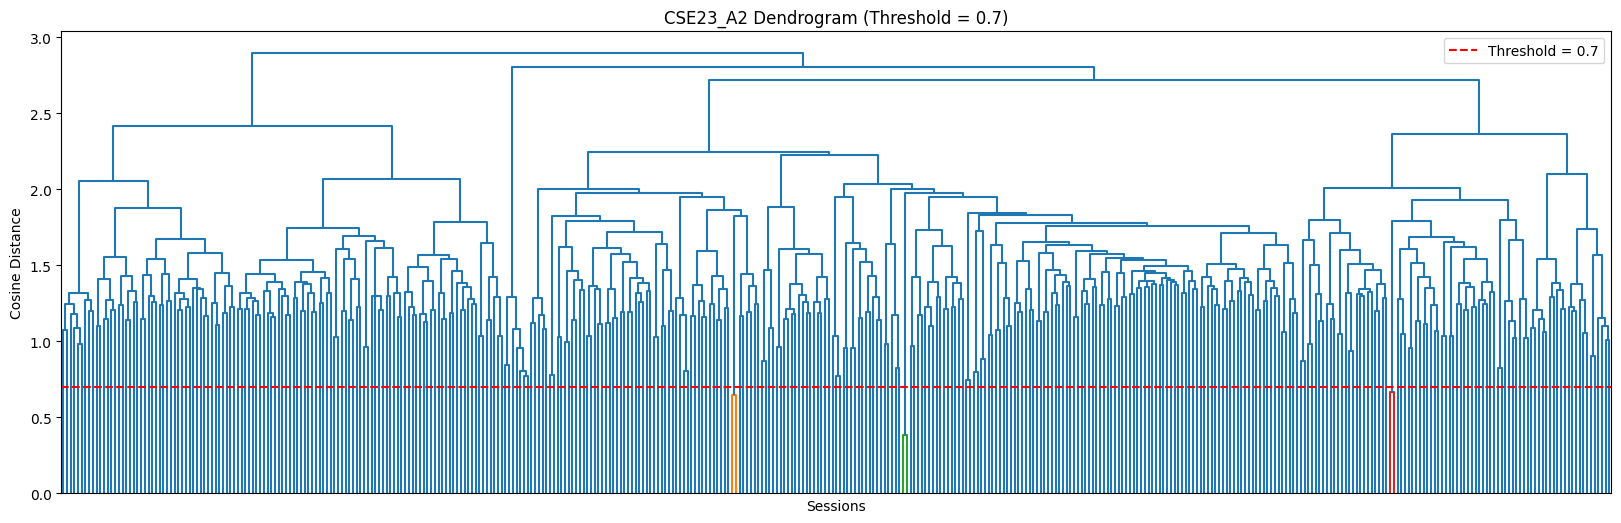

In [12]:
# ==== Step 6.1. Plot Dendrogram ====
plt.figure(figsize =(20, 6))
#dendrogram(Z, truncate_mode = "level", p = 5, no_labels = True, color_threshold = 0.6) # a simpler version
dendrogram(Z, no_labels = True, color_threshold = A2_AHC_THRESHOLD) # without truncated
plt.axhline(y = A2_AHC_THRESHOLD, color = "red", linestyle = "--", label = f"Threshold = {A2_AHC_THRESHOLD}")
plt.title(f"{conference_prefix}A2 Dendrogram (Threshold = {A2_AHC_THRESHOLD})")
plt.xlabel("Sessions")
plt.ylabel("Cosine Distance")
plt.legend()
plt.grid(False)
plt.show()

In [13]:
# ==== Step 7. Brief Summary (clean) ====
# counts by original labels (before small-cluster relabeling)
counts = df_A2["label"].value_counts().sort_index()
size_limit = A2_AHC_SIZE_LIMIT
valid_cluster_ids = counts[counts >= size_limit].index
n_total_clusters       = int(counts.size)
n_valid_clusters       = int(len(valid_cluster_ids))
n_singleton_clusters   = int((counts == 1).sum())  # exactly size==1 in original labels
n_final_clusters       = int(df_A2["final_cluster"].nunique())

print(f"\n=== Summary for {conference_prefix}A2 (Threshold = {A2_AHC_THRESHOLD} & ≥ {A2_AHC_SIZE_LIMIT} members) ===")
print(f"\nNumber of clusters formed (threshold = {A2_AHC_THRESHOLD}): {n_total_clusters}")
print(f"Number of valid clusters (≥ {size_limit} members): {n_valid_clusters}")
print(f"Number of clusters with exactly 1 member (singletons): {n_singleton_clusters}")
print(f"Final clusters (including cluster 0): {n_final_clusters}")

# ==== Step 8. Final-cluster sanity check ====
if n_final_clusters == 1 and df_A2["final_cluster"].iat[0] == 0:
    print("\n==== Only one final cluster remains: cluster 0. ====\nAll points were reassigned due to the minimum size rule.")
else:
    print(f"\nThere are {n_final_clusters} final clusters (including cluster 0).")


=== Summary for CSE23_A2 (Threshold = 0.7 & ≥ 1 members) ===

Number of clusters formed (threshold = 0.7): 414
Number of valid clusters (≥ 1 members): 414
Number of clusters with exactly 1 member (singletons): 411
Final clusters (including cluster 0): 414

There are 414 final clusters (including cluster 0).


In [14]:
# ==== Step 7. Brief Summary ====
n_total_clusters = len(np.unique(labels))
n_valid_clusters = len(valid_clusters)
n_singleton_clusters = (counts == 1).sum()
n_final_clusters = df_A2['final_cluster'].nunique()

print(f"\n=== Summary for {conference_prefix}A2 ({A2_AHC_THRESHOLD} & ≥ {A2_AHC_SIZE_LIMIT} members) ===")
print(f"\nNumber of clusters formed (threshold = {A2_AHC_THRESHOLD}): {n_total_clusters}")
print(f"Number of Valid clusters (≥ {A2_AHC_SIZE_LIMIT} members): {n_valid_clusters}")
print(f"Number of singleton clusters (exactly 1 member): {n_singleton_clusters}")
print(f"Final clusters (with cluster 0): {n_final_clusters}")
#print(df_A2["final_cluster"].value_counts())


# To print out the list of Invalid clusters and theris members:
#original_labels = df_A2["label"]
#final_labels = df_A2["final_cluster"]
#df_A2[df_A2["label"] != df_A2["final_cluster"]]["label"].value_counts()

# ==== Step 8. Check if only one final cluster remains ====
num_final_clusters = df_A2["final_cluster"].nunique()
if num_final_clusters == 1 and df_A2["final_cluster"].unique()[0] == 0:
    print("\n ==== Only one final cluster remains: Cluster 0. ====\nAll data points were merged into one cluster due to not meeting the minimum size threshold.")
else:
    print(f"\nThere are {num_final_clusters} final clusters.")


=== Summary for CSE23_A2 (0.7 & ≥ 1 members) ===

Number of clusters formed (threshold = 0.7): 414
Number of Valid clusters (≥ 1 members): 414
Number of singleton clusters (exactly 1 member): 411
Final clusters (with cluster 0): 414

There are 414 final clusters.


In [15]:
# ==== Step 9. Evaluation ====
score_all = silhouette_score(normalized_tfidf, df_A2["final_cluster"], metric = "cosine")
dbi_score = davies_bouldin_score(normalized_tfidf, df_A2["final_cluster"])

same_sims, diff_sims = [], []
for i in range(len(normalized_tfidf)):
    for j in range(i + 1, len(normalized_tfidf)):
        sim = cosine_similarity([normalized_tfidf[i]], [normalized_tfidf[j]])[0][0]
        if df_A2["final_cluster"][i] == df_A2["final_cluster"][j]:
            same_sims.append(sim)
        else:
            diff_sims.append(sim)

avg_same = np.mean(same_sims)
avg_diff = np.mean(diff_sims)
discriminative_gap = avg_same - avg_diff

# ==== Step 10. Display results ====
print(f"\n=== Evaluation for for {conference_prefix}A2 (Threshold = {A2_AHC_THRESHOLD} & ≥ {A2_AHC_SIZE_LIMIT} members) ===")
print(f"Number of clusters (final):   {df_A2['final_cluster'].nunique()}")
print(f"Discriminative Gap:           {discriminative_gap:.4f}")
print(f"Avg Same-Cluster Similarity:  {avg_same:.4f}")
print(f"Avg Diff-Cluster Similarity:  {avg_diff:.4f}")
print(f"Silhouette Score (cosine):    {score_all:.4f}")
print(f"Davies-Bouldin Index:         {dbi_score:.4f}")


=== Evaluation for for CSE23_A2 (Threshold = 0.7 & ≥ 1 members) ===
Number of clusters (final):   414
Discriminative Gap:           0.7837
Avg Same-Cluster Similarity:  0.8306
Avg Diff-Cluster Similarity:  0.0469
Silhouette Score (cosine):    0.0114
Davies-Bouldin Index:         0.2489


## B1: SBERT + PCA + KMeans (k = rooms)

In [16]:
# ==== Step 0. Configure PCA for Dimension Reduction ====
B_PCA_N_COMPONENTS = 10

# ==== Step 1. Preprocess for SBERT Embedding ====
texts = []
session_ids = []
mini_list = {}


# ==== Step 2. KEY CHANGES - Simulate the Original minisymposia.yaml Structure ====
mini_list = {}
for session_code, session in schd.items():
    if "talks" in session and len(session["talks"]) > 0: # ensure it's symposium
        title = session["title"] if "title" in session else ""
        abstract = session["abstract"] if "abstract" in session else ""
        talk_titles = [t["title"] for t in session["talks"] if "title" in t]
        talk_abstracts = [t["abstract"] for t in session["talks"] if "abstract" in t]

        mini_list[session_code] = {
            "title": title,
            "abstract": abstract,
            "talk_titles": talk_titles,
            "talk_abstracts": talk_abstracts,
        }
        content = f"{ms_title} {ms_abstract} {safe_join(talk_titles)} {safe_join(talk_abstracts)}"
        texts.append(content)
        session_ids.append(session_code)

In [17]:
# ==== Step 3. SBERT embeddings normalization (cosine clustering) ====
pca_sbert_embeddings = PCA(n_components=B_PCA_N_COMPONENTS).fit_transform(sbert_embeddings) # PCA
pca_normalized_sbert = normalize(pca_sbert_embeddings, norm = "l2") #for B1, B2

# ==== Step 4. Clustering with KMeans ====
# reference: https://scikit-learn.org/stable/modules/clustering.html#k-means
# reference: https://medium.com/@nerminhafeez2002/understanding-k-means-clustering-3716731cc648
# reference: https://anirbansen2709.medium.com/sbert-how-to-use-sentence-embeddings-to-solve-real-world-problems-f950aa300c72
NCLUSTERS = rooms
kmeans = KMeans(n_clusters = NCLUSTERS, random_state = 123, n_init = 10).fit(pca_normalized_sbert)
labels_B1 = kmeans.fit_predict(pca_normalized_sbert)

In [18]:
# ==== Step 5. Analyze clusters ====
cluster_results = []

for i in range(NCLUSTERS):
    cluster_indices = [j for j in range(len(session_ids)) if kmeans.labels_[j] == i]
    cluster_embeddings = [pca_normalized_sbert[j] for j in cluster_indices]
    cluster_titles = [mini_list[session_ids[j]]["title"] for j in cluster_indices]
    cluster_codes = [session_ids[j] for j in cluster_indices]

    # Compute cluster center
    center = np.mean(cluster_embeddings, axis = 0).reshape(1, -1)
    sims = cosine_similarity(cluster_embeddings, center).flatten()
    best_idx = np.argmax(sims)

    representative_title = cluster_titles[best_idx]
    representative_code = cluster_codes[best_idx]

    print(f"\n==== CLUSTER {i+1} ====")
    print("▶ Representative Title:", representative_title) # the minisymposia title closest to the cluster center
    for j in cluster_indices:
        print("  -", session_ids[j], ":", mini_list[session_ids[j]]["title"])

    for j in cluster_indices:
        cluster_results.append({
            "theme_id": i,
            "session_code": session_ids[j],
            "title": mini_list[session_ids[j]]["title"],
            "representative_title": representative_title
        })


==== CLUSTER 1 ====
▶ Representative Title: Robust Finite Element Methods for Convection-Diffusion Problems - Part I of II
  - MS6 : Discretization Methods with Provable Properties for the Robust Simulation of Nonlinear Partial Differential Equations - Part I of II
  - MS39 : Discretization Methods with Provable Properties for the Robust Simulation of Nonlinear Partial Differential Equations - Part II of II
  - MS81 : Constructing and Exploiting Discretizations with the Summation-by-Parts Property - Part I of II
  - MS105 : Structure Preserving and Robust Techniques for the Simulation of Transport Phenomena and Fluid Flows - Part I of II
  - MS117 : Constructing and Exploiting Discretizations with the Summation-by-Parts Property - Part II of II
  - MS122 : Geometric Mechanics Formulations and Associated Structure-Preserving Discretizations for Fluids - Part II of II
  - MS141 : Structure Preserving and Robust Techniques for the Simulation of Transport Phenomena and Fluid Flows - Part 

In [19]:
# ==== Step 6. Save Output to JSON ====
with open(f"{conference_prefix}B1_output_sbert_kmeans.json", "w") as f:
    json.dump(cluster_results, f, indent = 2)

print(f"\n COMPLETE! {len(cluster_results)} entries were saved.")


 COMPLETE! 417 entries were saved.


In [20]:
# ==== Step 7. Evaluation ====
# Silhouette Score (cosine)
sil_score = silhouette_score(pca_normalized_sbert, labels_B1, metric = "cosine")

# Davies-Bouldin Index
dbi_score = davies_bouldin_score(pca_normalized_sbert, labels_B1)

# Average Same-Cluster & Different-Cluster Similarities
same_sims = []
diff_sims = []

for i in range(len(pca_normalized_sbert)):
    for j in range(i + 1, len(pca_normalized_sbert)):
        sim = cosine_similarity([pca_normalized_sbert[i]], [pca_normalized_sbert[j]])[0][0]
        if labels_B1[i] == labels_B1[j]:
            same_sims.append(sim)
        else:
            diff_sims.append(sim)

avg_same = np.mean(same_sims)
avg_diff = np.mean(diff_sims)
discriminative_gap = avg_same - avg_diff

# ==== Step 8. Display result ====
print(f"=== Evaluation for {conference_prefix}B1 (PCA = {B_PCA_N_COMPONENTS}) (K = {rooms}) ===")
print(f"Discriminative Gap:           {discriminative_gap:.4f}")
print(f"Avg Same-Cluster Similarity:  {avg_same:.4f}")
print(f"Avg Diff-Cluster Similarity:  {avg_diff:.4f}")
print(f"Silhouette Score (cosine):    {sil_score:.4f}")
print(f"Davies-Bouldin Index:         {dbi_score:.4f}")

=== Evaluation for CSE23_B1 (PCA = 10) (K = 37) ===
Discriminative Gap:           0.7538
Avg Same-Cluster Similarity:  0.7292
Avg Diff-Cluster Similarity:  -0.0246
Silhouette Score (cosine):    0.3048
Davies-Bouldin Index:         1.4118


## B2: SBERT + PCA + AHC

In [21]:
# ==== Step 1. Agglomerative Clustering ====
B2_AHC_THRESHOLD = 0.7
B2_AHC_SIZE_LIMIT = 1

# Build linkage matrix
Z = linkage(pca_normalized_sbert, method = "ward", metric = "euclidean")

# Set distance_threshold = AHC_THRESHOLD
labels = fcluster(Z, t = B2_AHC_THRESHOLD, criterion = "distance") - 1

# ==== Step 2. Build DataFrame ====
df_B2 = pd.DataFrame({
    "code": session_ids,
    "label": labels,
    "title": [mini_list[code]["talk_titles"] for code in session_ids],
    "abstract": [mini_list[code]["talk_abstracts"] for code in session_ids]
})

# ==== Step 3. Identify small group (counts below AHC_SIZE_LIMIT) and turn it into CLUSTER 0 ====
counts = df_B2["label"].value_counts()
valid_clusters = counts[(counts >= B2_AHC_SIZE_LIMIT) & (counts.index != 0)].index
df_B2["final_cluster"] = df_B2["label"].apply(lambda x: x if x in valid_clusters else 0)

# ==== Step 4. Analyze clusters ====
cluster_results = []
labels_B2 = sorted(df_B2["final_cluster"].unique())  # including cluster 0

for label in labels_B2:
    cluster_indices = df_B2[df_B2["final_cluster"] == label].index.tolist()
    cluster_embeddings = [pca_normalized_sbert[j] for j in cluster_indices]
    cluster_titles = df_B2.loc[cluster_indices, "title"].tolist()
    cluster_codes = df_B2.loc[cluster_indices, "code"].tolist()

    center = np.mean(cluster_embeddings, axis = 0).reshape(1, -1)
    sims = cosine_similarity(cluster_embeddings, center).flatten()
    best_idx = np.argmax(sims)

    representative_title = cluster_titles[best_idx]
    representative_code = cluster_codes[best_idx]

    print(f"\n==== CLUSTER {label} ====")
    print("▶ Representative Title:", representative_title)

    for j in cluster_indices:
        print("  -", df_B2.loc[j, "code"], ":", df_B2.loc[j, "title"])

        cluster_results.append({
            "theme_id": int(label),
            "session_code": df_B2.loc[j, "code"],
            "title": df_B2.loc[j, "title"],
            "representative_title": representative_title
        })


==== CLUSTER 0 ====
▶ Representative Title: ['Surrogation Methods for Nonconvex Nondifferential Problems in Finite Dimensions', 'Inexact Proximal Newton Methods in Hilbert Spaces', 'From Perspective Maps to Epigraphical Projections', 'An Inexact Trust-Region Algorithm for Nonsmooth Nonconvex Optimization', 'Regularized Smoothing for Solution Mappings of Convex Problems, with Applications to Two-Stage Stochastic Programming and Some Hierarchical Problems']
  - MS215 : ['Surrogation Methods for Nonconvex Nondifferential Problems in Finite Dimensions', 'Inexact Proximal Newton Methods in Hilbert Spaces', 'From Perspective Maps to Epigraphical Projections', 'An Inexact Trust-Region Algorithm for Nonsmooth Nonconvex Optimization', 'Regularized Smoothing for Solution Mappings of Convex Problems, with Applications to Two-Stage Stochastic Programming and Some Hierarchical Problems']
  - MS252 : ['Proximal Quasi-Newton Methods for Nonsmooth Regularized Bound-Constrained Optimization', 'An Inte

In [22]:
# ==== Step 5. Save Output to JSON ====
with open(f"{conference_prefix}B2_output_sbert_hierarchical_clusters.json", "w") as f:
    json.dump(cluster_results, f, indent = 2)
print(f"\n COMPLETE! {len(cluster_results)} entries were saved.")


 COMPLETE! 417 entries were saved.


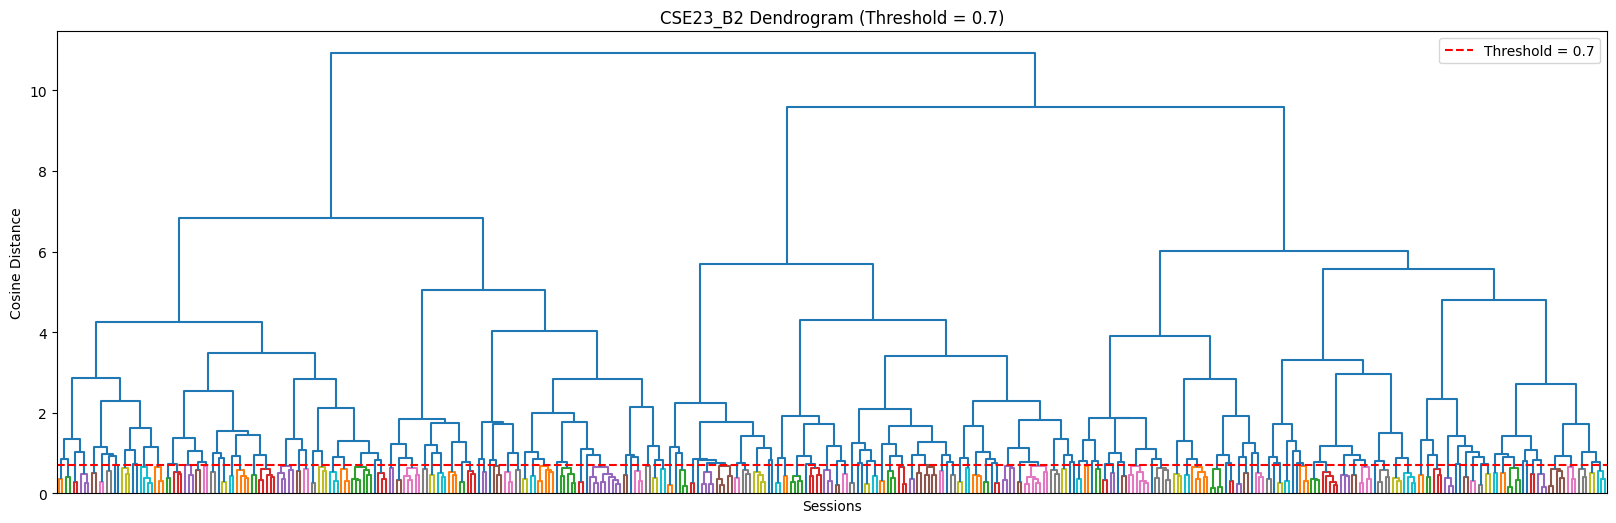

In [23]:
# ==== Step 6. Plot Dendrogram ====
plt.figure(figsize =(20, 6))
#dendrogram(Z, truncate_mode = "level", p = 5, no_labels = True, color_threshold = AHC_THRESHOLD) # a simpler version
dendrogram(Z, no_labels = True, color_threshold = B2_AHC_THRESHOLD) # without truncated
plt.axhline(y = B2_AHC_THRESHOLD, color = "red", linestyle = "--", label = f"Threshold = {B2_AHC_THRESHOLD}")
plt.title(f"{conference_prefix}B2 Dendrogram (Threshold = {B2_AHC_THRESHOLD})")
plt.xlabel("Sessions")
plt.ylabel("Cosine Distance")
plt.legend()
plt.grid(False)
plt.show()

In [24]:
# ==== Step 7. Brief Summary ====
# Counts by original labels (before small-cluster relabeling)
counts = df_B2["label"].value_counts().sort_index()
size_limit = B2_AHC_SIZE_LIMIT
valid_cluster_ids   = counts[counts >= size_limit].index

n_total_clusters       = int(counts.size)                       # clusters formed at the threshold
n_valid_clusters       = int(len(valid_cluster_ids))            # clusters with size >= size_limit
n_singleton_clusters   = int((counts == 1).sum())               # exactly 1 member (before relabeling)
n_final_clusters       = int(df_B2["final_cluster"].nunique())  # after relabeling small clusters to 0

print(f"\n=== Summary for {conference_prefix}B2 (Threshold = {B2_AHC_THRESHOLD} & ≥ {B2_AHC_SIZE_LIMIT} members) ===")
print(f"\nNumber of clusters formed (threshold = {B2_AHC_THRESHOLD}): {n_total_clusters}")
print(f"Number of valid clusters (≥ {size_limit} members): {n_valid_clusters}")
print(f"Number of singleton clusters (exactly 1 member): {n_singleton_clusters}")
print(f"Final clusters (including cluster 0): {n_final_clusters}")


# ==== Step 8. Final-cluster sanity check ====
final_labels = df_B2["final_cluster"].unique()
if n_final_clusters == 1 and len(final_labels) == 1 and final_labels[0] == 0:
    print("\n==== Only one final cluster remains: cluster 0. ====\nAll points were reassigned due to the minimum size rule.")
else:
    print(f"\nThere are {n_final_clusters} final clusters (including cluster 0).")


=== Summary for CSE23_B2 (Threshold = 0.7 & ≥ 1 members) ===

Number of clusters formed (threshold = 0.7): 170
Number of valid clusters (≥ 1 members): 170
Number of singleton clusters (exactly 1 member): 35
Final clusters (including cluster 0): 170

There are 170 final clusters (including cluster 0).


In [25]:
# ==== Step 9. Evaluation ====
score_all = silhouette_score(pca_normalized_sbert, df_B2["final_cluster"], metric = "cosine")
dbi_score = davies_bouldin_score(pca_normalized_sbert, df_B2["final_cluster"])

same_sims, diff_sims = [], []
for i in range(len(pca_normalized_sbert)):
    for j in range(i + 1, len(pca_normalized_sbert)):
        sim = cosine_similarity([pca_normalized_sbert[i]], [pca_normalized_sbert[j]])[0][0]
        if df_B2["final_cluster"][i] == df_B2["final_cluster"][j]:
            same_sims.append(sim)
        else:
            diff_sims.append(sim)

avg_same = np.mean(same_sims)
avg_diff = np.mean(diff_sims)
discriminative_gap = avg_same - avg_diff

# ==== Step 10. Display results ====
print(f"=== Evaluation for {conference_prefix}B2 (PCA = {B_PCA_N_COMPONENTS}) B2 (Threshold = {B2_AHC_THRESHOLD} & ≥ {B2_AHC_SIZE_LIMIT} members) ===")
print(f"Number of clusters (final):   {df_B2["final_cluster"].nunique()}")
print(f"Discriminative Gap:           {discriminative_gap:.4f}")
print(f"Avg Same-Cluster Similarity:  {avg_same:.4f}")
print(f"Avg Diff-Cluster Similarity:  {avg_diff:.4f}")
print(f"Silhouette Score (cosine):    {score_all:.4f}")
print(f"Davies-Bouldin Index:         {dbi_score:.4f}")

=== Evaluation for CSE23_B2 (PCA = 10) B2 (Threshold = 0.7 & ≥ 1 members) ===
Number of clusters (final):   170
Discriminative Gap:           0.8986
Avg Same-Cluster Similarity:  0.8922
Avg Diff-Cluster Similarity:  -0.0064
Silhouette Score (cosine):    0.3699
Davies-Bouldin Index:         0.8238


## C1: Specter2 + PCA + KMeans (k = rooms)

In [26]:
# ==== Step 0. Configure PCA for Dimension Reduction ====
C_PCA_N_COMPONENTS = 10

# ==== Step 1. SPECTER2 embeddings normalization (cosine clustering) ====
pca_sbert_embeddings = PCA(n_components=C_PCA_N_COMPONENTS).fit_transform(sbert_embeddings) # PCA
pca_normalized_specter = normalize(specter_embeddings, norm = "l2") #for C1, C2

# ==== Step 2. Clustering with KMeans ====
NCLUSTERS = rooms
kmeans = KMeans(n_clusters = NCLUSTERS, random_state = 123, n_init = 10).fit(pca_normalized_specter)
labels_C1 = kmeans.fit_predict(pca_normalized_specter)

In [27]:
# ==== Step 3. KEY CHANGES - Simulate the Original minisymposia.yaml Structure ====
texts = []
session_ids = []
mini_list = {}

for session_code, session in schd.items():
    if "talks" in session and len(session["talks"]) > 0: # ensure it's symposium
        ms_title = session["title"] if "title" in session else ""
        ms_abstract = session["abstract"] if "abstract" in session else ""
        talk_titles = [t["title"] for t in session["talks"] if "title" in t]
        talk_abstracts = [t["abstract"] for t in session["talks"] if "abstract" in t]

        mini_list[session_code] = {
            "title": ms_title,
            "abstract": ms_abstract,
            "talk_titles": talk_titles,
            "talk_abstracts": talk_abstracts,
        }
        content = f"{ms_title} {ms_abstract} {safe_join(talk_titles)} {safe_join(talk_abstracts)}"
        texts.append(content)
        session_ids.append(session_code)

In [28]:
# ==== Step 4. Analyze clusters ====
cluster_results = []

for i in range(NCLUSTERS):
    cluster_indices = [j for j in range(len(session_ids)) if kmeans.labels_[j] == i]
    cluster_embeddings = [pca_normalized_specter[j] for j in cluster_indices]
    cluster_titles = [mini_list[session_ids[j]]["title"] for j in cluster_indices]
    cluster_codes = [session_ids[j] for j in cluster_indices]

    center = np.mean(cluster_embeddings, axis = 0).reshape(1, -1)
    sims = cosine_similarity(cluster_embeddings, center).flatten()
    best_idx = np.argmax(sims)

    representative_title = cluster_titles[best_idx]
    representative_code = cluster_codes[best_idx]

    print(f"\n==== CLUSTER {i+1} ====")
    print("▶ Representative Title:", representative_title)
    for j in cluster_indices:
        print("  -", session_ids[j], ":", mini_list[session_ids[j]]["title"])

    for j in cluster_indices:
        cluster_results.append({
            "theme_id": i,
            "session_code": session_ids[j],
            "title": mini_list[session_ids[j]]["title"],
            "representative_title": representative_title
        })


==== CLUSTER 1 ====
▶ Representative Title: Multi-Fidelity Methods for Uncertainty Quantification and Optimization - Part II of II
  - MS100 : Randomized Solvers in Large-Scale Scientific Computing - Part I of II
  - MS103 : Recent Advances in Stochastic Optimization and Computational Game Theory - Part I of II
  - MS108 : Advanced UQ with Challenging Models - Software and Methods - Part II of II
  - MS123 : High-Dimensional Approximation and Reduced-Order Models - Part II of II
  - MS128 : Novel Multilevel Methods for Uncertainty Quantification
  - MS291 : Bayesian Inference and Density Estimation
  - MS404 : Multi-Fidelity Methods for Uncertainty Quantification and Optimization - Part II of II

==== CLUSTER 2 ====
▶ Representative Title: On the Mutual Benefit of  Machine Learning and Domain Decomposition/Multilevel Methods - Part II of II
  - MS3 : Alleviating the Memory Footprint of Backpropagation
  - MS85 : Forward Alternatives to Back-Propagation in ML and Science
  - MS93 : Neu

In [29]:
# ==== Step 5. Save Output to JSON ====
with open(f"{conference_prefix}C1_output_specter2_kmeans.json", "w") as f:
    json.dump(cluster_results, f, indent = 2)

print(f"\n COMPLETE! {len(cluster_results)} entries were saved.")


 COMPLETE! 417 entries were saved.


In [30]:
# ==== Step 6. Evaluation ====
# Silhouette Score (cosine)
sil_score = silhouette_score(pca_normalized_specter, labels_C1, metric = "cosine")

# Davies-Bouldin Index
dbi_score = davies_bouldin_score(pca_normalized_specter, labels_C1)

# Average Same-Cluster & Different-Cluster Similarities
same_sims = []
diff_sims = []

for i in range(len(pca_normalized_specter)):
    for j in range(i + 1, len(pca_normalized_specter)):
        sim = cosine_similarity([pca_normalized_specter[i]], [pca_normalized_specter[j]])[0][0]
        if labels_C1[i] == labels_C1[j]:
            same_sims.append(sim)
        else:
            diff_sims.append(sim)

avg_same = np.mean(same_sims)
avg_diff = np.mean(diff_sims)
discriminative_gap = avg_same - avg_diff

# ==== Step 8. Display result ====
print(f"=== Evaluation for {conference_prefix}C1 (PCA = {C_PCA_N_COMPONENTS}) (K = {rooms}) ===")
print(f"Discriminative Gap:           {discriminative_gap:.4f}")
print(f"Avg Same-Cluster Similarity:  {avg_same:.4f}")
print(f"Avg Diff-Cluster Similarity:  {avg_diff:.4f}")
print(f"Silhouette Score (cosine):    {sil_score:.4f}")
print(f"Davies-Bouldin Index:         {dbi_score:.4f}")

=== Evaluation for CSE23_C1 (PCA = 10) (K = 37) ===
Discriminative Gap:           0.0439
Avg Same-Cluster Similarity:  0.9379
Avg Diff-Cluster Similarity:  0.8940
Silhouette Score (cosine):    0.0989
Davies-Bouldin Index:         2.3290


## C2: Specter2 + PCA + AHC

In [31]:
# ==== Step 1. Agglomerative Clustering ====
C2_AHC_THRESHOLD = 0.7
C2_AHC_SIZE_LIMIT = 1

# Build linkage matrix
Z = linkage(pca_normalized_specter, method = "ward", metric = "euclidean")

# Set distance_threshold = AHC_THRESHOLD
labels = fcluster(Z, t = C2_AHC_THRESHOLD, criterion = "distance") - 1

# ==== Step 2. Build DataFrame ====
df_C2 = pd.DataFrame({
    "code": session_ids,
    "label": labels,
    "title": [mini_list[code]["talk_titles"] for code in session_ids],
    "abstract": [mini_list[code]["talk_abstracts"] for code in session_ids]
})

# ==== Step 3. Identify small group (counts below 5) and turn it into CLUSTER 0 ====
counts = df_C2["label"].value_counts()
valid_clusters = counts[(counts >= C2_AHC_SIZE_LIMIT) & (counts.index != 0)].index
df_C2["final_cluster"] = df_B2["label"].apply(lambda x: x if x in valid_clusters else 0)

# ==== Step 4. Analyze clusters ====
cluster_results = []
labels_C2 = sorted(df_C2["final_cluster"].unique())  # including cluster 0

for label in labels_C2:
    cluster_indices = df_C2[df_C2["final_cluster"] == label].index.tolist()
    cluster_embeddings = [pca_normalized_specter[j] for j in cluster_indices]
    cluster_titles = df_C2.loc[cluster_indices, "title"].tolist()
    cluster_codes = df_C2.loc[cluster_indices, "code"].tolist()

    center = np.mean(cluster_embeddings, axis = 0).reshape(1, -1)
    sims = cosine_similarity(cluster_embeddings, center).flatten()
    best_idx = np.argmax(sims)

    representative_title = cluster_titles[best_idx]
    representative_code = cluster_codes[best_idx]

    print(f"\n==== CLUSTER {label} ====")
    print("▶ Representative Title:", representative_title)

    for j in cluster_indices:
        print("  -", df_C2.loc[j, "code"], ":", df_C2.loc[j, "title"])

        cluster_results.append({
            "theme_id": int(label),
            "session_code": df_C2.loc[j, "code"],
            "title": df_C2.loc[j, "title"],
            "representative_title": representative_title
        })


==== CLUSTER 0 ====
▶ Representative Title: ['A Parallel Dynamical Low-Rank Integrator for Radiation Transport', 'A Large-Stepsize Integrator for Charged-Particle Dynamics in a Strong Magnetic Field', 'On Low-Rank Tensor Product Approximations for the Stationary Radiative Transfer Equation', 'Variable Dynamic Mode Decomposition for Model Order Reduction in Multiscale Particle Transport Problems']
  - MS1 : ['Robust Science Roadmap: Challenges in Software Systems and High Throughput Computing Applications', 'Edge Computing as a Missing Link in the Post Moore Era', 'High-throughput Applications in Computational Medicine', 'Environmental Energy-Aware Computing applied High Throughput Applications']
  - MS3 : ['Revolve and Its Extensions', 'Checkpoint Code Generation in Julia for Numerical Simulations', 'Gradient Checkpointing for Training Neural Networks', 'Offloading to Nvme: A Hardware Alternative to Checkpointing', 'Blessing of Nonconvexity in Factorized Models']
  - MS4 : ['How Dark 

In [32]:
# ==== Step 5. Save Output to JSON ====
with open(f"{conference_prefix}C2_output_specter2_hierarchical_clusters.json", "w") as f:
    json.dump(cluster_results, f, indent = 2)
print(f"\n COMPLETE! {len(cluster_results)} entries were saved.")


 COMPLETE! 417 entries were saved.


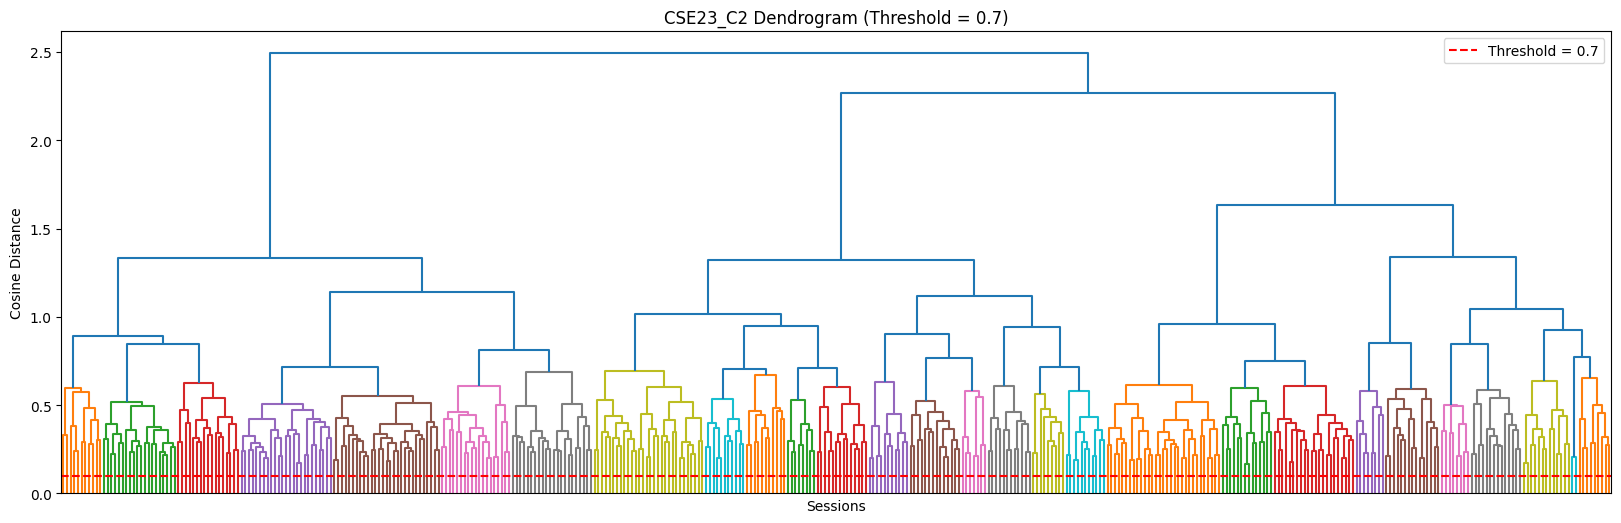

In [33]:
# ==== Step 6. Plot Dendrogram ====
plt.figure(figsize =(20, 6))
#dendrogram(Z, truncate_mode = "level", p = 5, no_labels = True, color_threshold = AHC_THRESHOLD) # a simpler version
dendrogram(Z, no_labels = True, color_threshold = C2_AHC_THRESHOLD) # without truncated
plt.axhline(y = 0.1, color = "red", linestyle = "--", label = f"Threshold = {C2_AHC_THRESHOLD}")
plt.title(f"{conference_prefix}C2 Dendrogram (Threshold = {C2_AHC_THRESHOLD})")
plt.xlabel("Sessions")
plt.ylabel("Cosine Distance")
plt.legend()
plt.grid(False)
plt.show()

In [34]:
# ==== Step 7. Brief Summary ====
# Counts by original labels (before small-cluster relabeling)
counts = df_C2["label"].value_counts().sort_index()
size_limit = C2_AHC_SIZE_LIMIT  # make sure this is defined earlier
valid_cluster_ids   = counts[counts >= size_limit].index

n_total_clusters       = int(counts.size)                       # clusters formed at the threshold
n_valid_clusters       = int(len(valid_cluster_ids))            # clusters with size >= size_limit
n_singleton_clusters   = int((counts == 1).sum())               # exactly 1 member (before relabeling)
n_final_clusters       = int(df_C2["final_cluster"].nunique())  # after relabeling small clusters to 0

# Optional: include method if you have C2_AHC_METHOD defined
header = f"Summary for C2 (Threshold = {C2_AHC_THRESHOLD} & ≥ {size_limit} members)"
# header = f"Summary for C2 (Method = {C2_AHC_METHOD}, Threshold = {C2_AHC_THRESHOLD} & ≥ {size_limit} members)"

print(f"\n=== {header} ===")
print(f"\nNumber of clusters formed (threshold = {C2_AHC_THRESHOLD}): {n_total_clusters}")
print(f"Number of valid clusters (≥ {size_limit} members): {n_valid_clusters}")
print(f"Number of singleton clusters (exactly 1 member): {n_singleton_clusters}")
print(f"Final clusters (including cluster 0): {n_final_clusters}")

# ==== Step 8. Final-cluster sanity check ====
final_labels = df_C2["final_cluster"].unique()
if n_final_clusters == 1 and len(final_labels) == 1 and final_labels[0] == 0:
    print("\n==== Only one final cluster remains: cluster 0. ====\nAll points were reassigned due to the minimum size rule.")
else:
    print(f"\nThere are {n_final_clusters} final clusters (including cluster 0).")



=== Summary for C2 (Threshold = 0.7 & ≥ 1 members) ===

Number of clusters formed (threshold = 0.7): 28
Number of valid clusters (≥ 1 members): 28
Number of singleton clusters (exactly 1 member): 0
Final clusters (including cluster 0): 28

There are 28 final clusters (including cluster 0).


In [35]:
# ==== Step 9. Check if only one final cluster remains ====
df_C2

,code,label,title,abstract,final_cluster
0,MS1,20,[Robust Science Roadmap: Challenges in Softwar...,[While trust in and reproducibility of scienti...,0
1,MS2,4,[Estimating a Potential Without the Agony of t...,"[None, None, None]",10
2,MS3,4,"[Revolve and Its Extensions, Checkpoint Code G...","[None, None, None, None, Factorized models, fr...",0
3,MS4,9,"[How Dark Is the Unilluminable Room?, On the S...",[The 1958 Christmas issue of The New Scientist...,0
4,MS5,20,[Productivity of Large Community Codes on the ...,[Fugaku is a supercomputer jointly developed b...,0
...,...,...,...,...,...
412,MS418,4,[Machine Learning Structure Preserving Bracket...,[Forecasting of time-series data requires impo...,0
413,MS419,7,[Multiple Invariants-Preserving Relaxation Run...,"[Relaxation Runge-Kutta methods, which are a s...",0
414,MS420,2,[Robust and Tractable Multidimensional Exponen...,[Given samples a multidimensional signal of th...,0
415,MS421,6,[An Adaptive Scheme for the Optimization of Da...,"[In this work, the problem of optimizing dampe...",0


In [36]:
# ==== Step 10. Evaluation ====
score_all = silhouette_score(pca_normalized_specter, df_C2["final_cluster"], metric = "cosine")
dbi_score = davies_bouldin_score(pca_normalized_specter, df_C2["final_cluster"])

same_sims, diff_sims = [], []
for i in range(len(pca_normalized_specter)):
    for j in range(i + 1, len(pca_normalized_specter)):
        sim = cosine_similarity([pca_normalized_specter[i]], [pca_normalized_specter[j]])[0][0]
        if df_C2["final_cluster"][i] == df_C2["final_cluster"][j]:
            same_sims.append(sim)
        else:
            diff_sims.append(sim)

avg_same = np.mean(same_sims)
avg_diff = np.mean(diff_sims)
discriminative_gap = avg_same - avg_diff

# ==== Step 10. Display results ====
print(f"=== Evaluation for {conference_prefix}C2 (PCA = {C_PCA_N_COMPONENTS})(Threshold = {C2_AHC_THRESHOLD} & ≥ {C2_AHC_SIZE_LIMIT} members) ===")
print(f"Number of clusters (final):   {df_C2["final_cluster"].nunique()}")
print(f"Discriminative Gap:           {discriminative_gap:.4f}")
print(f"Avg Same-Cluster Similarity:  {avg_same:.4f}")
print(f"Avg Diff-Cluster Similarity:  {avg_diff:.4f}")
print(f"Silhouette Score (cosine):    {score_all:.4f}")
print(f"Davies-Bouldin Index:         {dbi_score:.4f}")

=== Evaluation for CSE23_C2 (PCA = 10)(Threshold = 0.7 & ≥ 1 members) ===
Number of clusters (final):   28
Discriminative Gap:           0.0026
Avg Same-Cluster Similarity:  0.8961
Avg Diff-Cluster Similarity:  0.8935
Silhouette Score (cosine):    -0.2178
Davies-Bouldin Index:         1.6088


## Stage 4: Compare results

In [37]:
# ==== Step 1. Evaluate the discriminative power ====
def evaluate_clustering(embedding, labels, model_name, model_number, model_params):
    embedding = np.array(embedding)
    sim_matrix = cosine_similarity(embedding)

    same_sims, diff_sims = [], []
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            sim = sim_matrix[i][j]
            if labels[i] == labels[j]:
                same_sims.append(sim)
            else:
                diff_sims.append(sim)

    # Compute metrics
    same_avg = np.mean(same_sims)
    diff_avg = np.mean(diff_sims)
    gap = same_avg - diff_avg
    sil_score = silhouette_score(embedding, labels, metric = "cosine")
    db_index = davies_bouldin_score(embedding, labels)
    n_clusters = len(set(labels))

    return {
        "Model Num.": model_number,
        "Model Name": model_name,
        "Params": model_params,
        "Clusters Counts": n_clusters,
        "Discriminative Gap": gap,
        "Avg. Same-Cluster-Sim": same_avg,
        "Avg. Diff-Cluster-Sim": diff_avg,
        "Silhouette Score": sil_score,
        "Davies-Bouldin Index": db_index,
    }

# ==== Step 2. Display Results ====
results = []

# A1, A2
results.append(evaluate_clustering(normalized_tfidf, labels_A1, "TF-IDF + KMeans", f"{conference_prefix}A1", f"k={rooms}"))
results.append(evaluate_clustering(normalized_tfidf, df_A2["final_cluster"].values, "TF-IDF + Hierarchical Clusters",f"{conference_prefix}A2", f"threshold={A2_AHC_THRESHOLD}"))

# B1, B2
results.append(evaluate_clustering(pca_normalized_sbert, labels_B1, "SBERT + PCA + KMeans", f"{conference_prefix}B1",f"pca={B_PCA_N_COMPONENTS},k={rooms}"))
results.append(evaluate_clustering(pca_normalized_sbert, df_B2["final_cluster"].values, "SBERT + PCA + AHC", f"{conference_prefix}B2",f"pca={B_PCA_N_COMPONENTS}, threshold={B2_AHC_THRESHOLD}"))

# C1, C2
results.append(evaluate_clustering(pca_normalized_specter, labels_C1, "Specter2 + PCA + KMeans", f"{conference_prefix}C1",f"pca={C_PCA_N_COMPONENTS}, k={rooms}"))
results.append(evaluate_clustering(pca_normalized_specter, df_C2["final_cluster"].values, "Specter2 + PCA + AHC", f"{conference_prefix}C2",f"pca={C_PCA_N_COMPONENTS}, threshold={C2_AHC_THRESHOLD}"))

df_results = pd.DataFrame(results).round(4)

display(
    df_results.style
        .format(precision = 4)
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left")]},
            {"selector": "td", "props": [("text-align", "left")]}
        ])
        .hide(axis = "index")
)

df_results.to_excel(conference_prefix+"clustering_results.xlsx")
df_results.to_json(conference_prefix+"clustering_results.json", orient="records")

Model Num.,Model Name,Params,Clusters Counts,Discriminative Gap,Avg. Same-Cluster-Sim,Avg. Diff-Cluster-Sim,Silhouette Score,Davies-Bouldin Index
CSE23_A1,TF-IDF + KMeans,k=37,37,0.0781,0.1224,0.0444,0.0438,3.6927
CSE23_A2,TF-IDF + Hierarchical Clusters,threshold=0.7,414,0.7837,0.8306,0.0469,0.0114,0.2489
CSE23_B1,SBERT + PCA + KMeans,"pca=10,k=37",37,0.7538,0.7292,-0.0246,0.3048,1.4118
CSE23_B2,SBERT + PCA + AHC,"pca=10, threshold=0.7",170,0.8986,0.8922,-0.0064,0.3699,0.8238
CSE23_C1,Specter2 + PCA + KMeans,"pca=10, k=37",37,0.0439,0.9379,0.8940,0.0989,2.3290
CSE23_C2,Specter2 + PCA + AHC,"pca=10, threshold=0.7",28,0.0026,0.8962,0.8935,-0.2178,1.6088


## Analysis

In [38]:
cse = ["CSE19", "CSE23", "CSE25"]

dfs = [pd.read_json(f"{c}_clustering_results.json") for c in cse]
raw = pd.concat(dfs, ignore_index=True)

display(raw)

,Model Num.,Model Name,Params,Clusters Counts,Discriminative Gap,Avg. Same-Cluster-Sim,Avg. Diff-Cluster-Sim,Silhouette Score,Davies-Bouldin Index
0,CSE19_A1,TF-IDF + KMeans,k=38,38,0.0961,0.1387,0.0426,0.0550,3.4726
1,CSE19_A2,TF-IDF + Hierarchical Clusters,threshold=0.7,419,0.7880,0.8333,0.0453,0.0073,0.2247
2,CSE19_B1,SBERT + PCA + KMeans,"pca=10,k=38",38,0.7731,0.7505,-0.0227,0.2906,1.4412
3,CSE19_B2,SBERT + PCA + AHC,"pca=10, threshold=0.7",164,0.9065,0.9005,-0.0060,0.3618,0.8333
4,CSE19_C1,Specter2 + PCA + KMeans,"pca=10, k=38",38,0.0460,0.9309,0.8849,0.0926,2.2942
5,CSE19_C2,Specter2 + PCA + AHC,"pca=10, threshold=0.7",31,0.0032,0.8877,0.8845,-0.1652,1.7684
6,CSE23_A1,TF-IDF + KMeans,k=37,37,0.0781,0.1224,0.0444,0.0438,3.6927
7,CSE23_A2,TF-IDF + Hierarchical Clusters,threshold=0.7,414,0.7837,0.8306,0.0469,0.0114,0.2489
8,CSE23_B1,SBERT + PCA + KMeans,"pca=10,k=37",37,0.7538,0.7292,-0.0246,0.3048,1.4118
9,CSE23_B2,SBERT + PCA + AHC,"pca=10, threshold=0.7",170,0.8986,0.8922,-0.0064,0.3699,0.8238


'Clustering results (combined)'

,ModelNum,ModelName,Params,ClusterCount,DiscriminativeGap,AvgSameClusterSim,AvgDiffClusterSim,Silhouette,DBI,Conference,Embedding,Algorithm,IsOptimal
0,CSE19_A1,TF-IDF + KMeans,k=38,38,0.0961,0.1387,0.0426,0.0550,3.4726,CSE19,TF-IDF,KMeans,False
1,CSE19_A2,TF-IDF + Hierarchical Clusters,threshold=0.7,419,0.7880,0.8333,0.0453,0.0073,0.2247,CSE19,TF-IDF,AHC,False
2,CSE19_B1,SBERT + PCA + KMeans,"pca=10,k=38",38,0.7731,0.7505,-0.0227,0.2906,1.4412,CSE19,SBERT,PCA+KMeans,False
3,CSE19_B2,SBERT + PCA + AHC,"pca=10, threshold=0.7",164,0.9065,0.9005,-0.0060,0.3618,0.8333,CSE19,SBERT,PCA+AHC,False
4,CSE19_C1,Specter2 + PCA + KMeans,"pca=10, k=38",38,0.0460,0.9309,0.8849,0.0926,2.2942,CSE19,Specter2,PCA+KMeans,False
5,CSE19_C2,Specter2 + PCA + AHC,"pca=10, threshold=0.7",31,0.0032,0.8877,0.8845,-0.1652,1.7684,CSE19,Specter2,PCA+AHC,False
6,CSE23_A1,TF-IDF + KMeans,k=37,37,0.0781,0.1224,0.0444,0.0438,3.6927,CSE23,TF-IDF,KMeans,False
7,CSE23_A2,TF-IDF + Hierarchical Clusters,threshold=0.7,414,0.7837,0.8306,0.0469,0.0114,0.2489,CSE23,TF-IDF,AHC,False
8,CSE23_B1,SBERT + PCA + KMeans,"pca=10,k=37",37,0.7538,0.7292,-0.0246,0.3048,1.4118,CSE23,SBERT,PCA+KMeans,False
9,CSE23_B2,SBERT + PCA + AHC,"pca=10, threshold=0.7",170,0.8986,0.8922,-0.0064,0.3699,0.8238,CSE23,SBERT,PCA+AHC,False


'Aggregate metrics by (Embedding, Algorithm)'

,Embedding,Algorithm,mean_sil,mean_dbi,mean_gap,count
0,SBERT,PCA+AHC,0.373500,0.811900,0.901467,3
1,SBERT,PCA+KMeans,0.307533,1.423533,0.757767,3
2,Specter2,PCA+AHC,-0.209000,1.669033,0.003600,3
3,Specter2,PCA+KMeans,0.099867,2.307533,0.042333,3
4,TF-IDF,AHC,0.009633,0.246000,0.774267,3
5,TF-IDF,KMeans,0.049167,3.566367,0.084500,3


{'combined_csv': 'clustering_results_combined.csv',
 'summary_csv': 'clustering_results_summary.csv',
 'excel_path': 'clustering_results_summary.xlsx',
 'aggregate_csv': 'aggregate_by_method.csv',
 'plots': []}

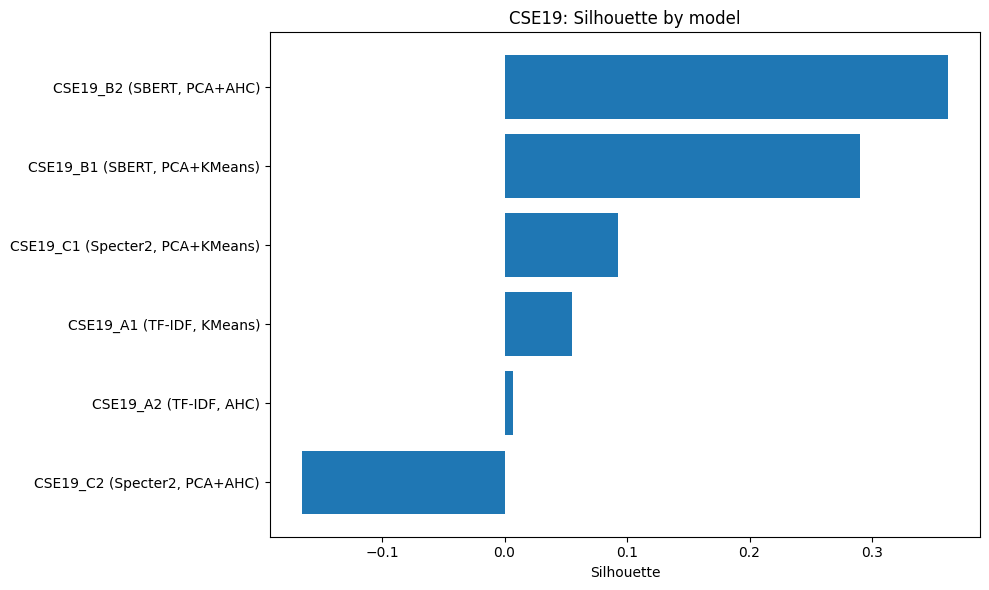

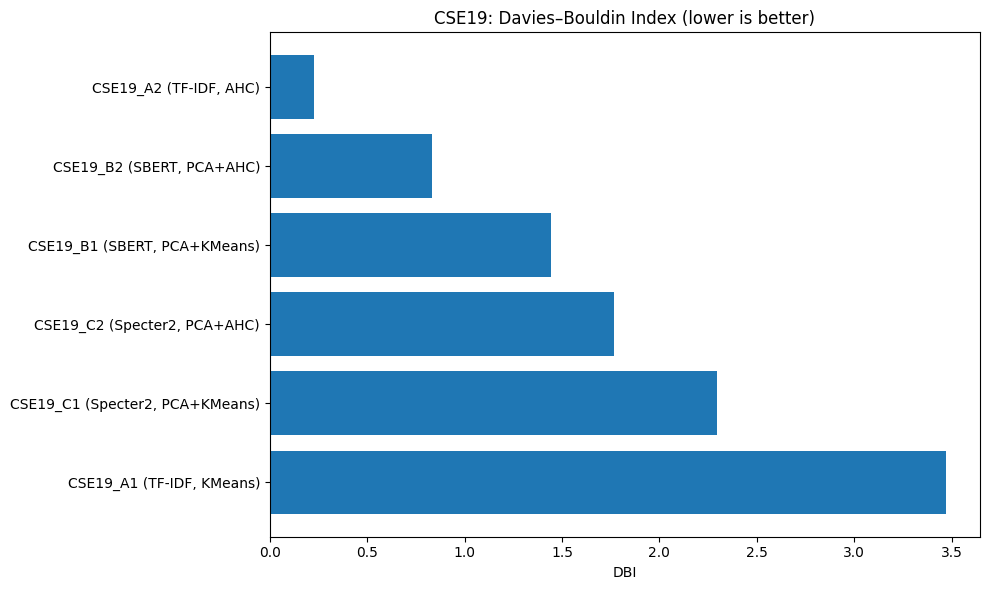

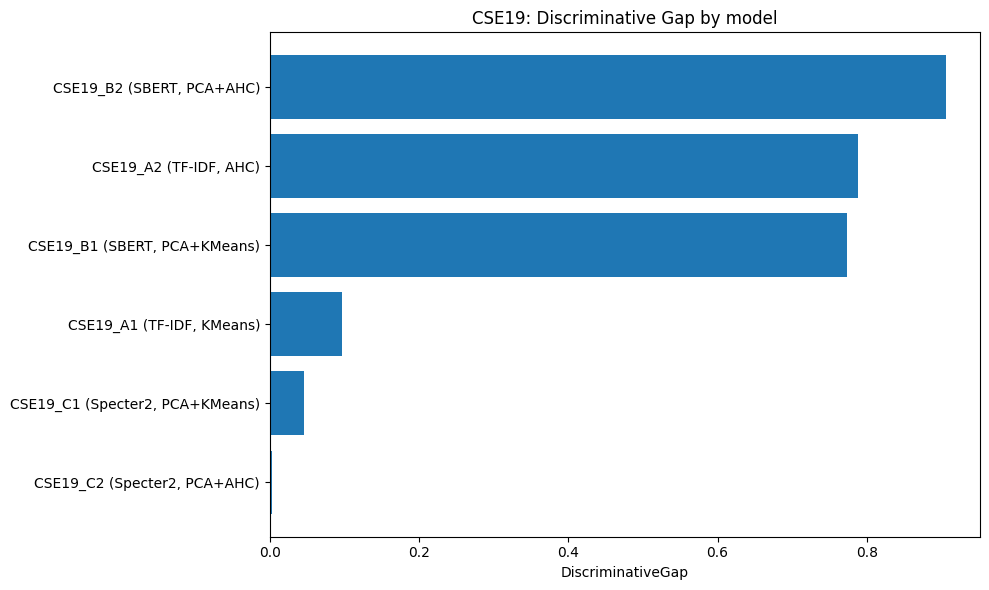

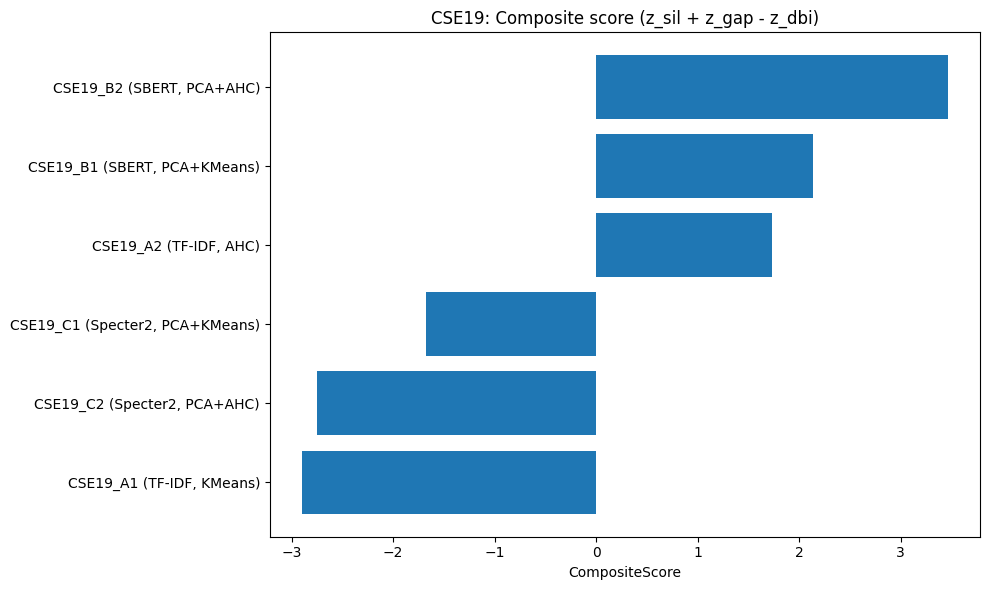

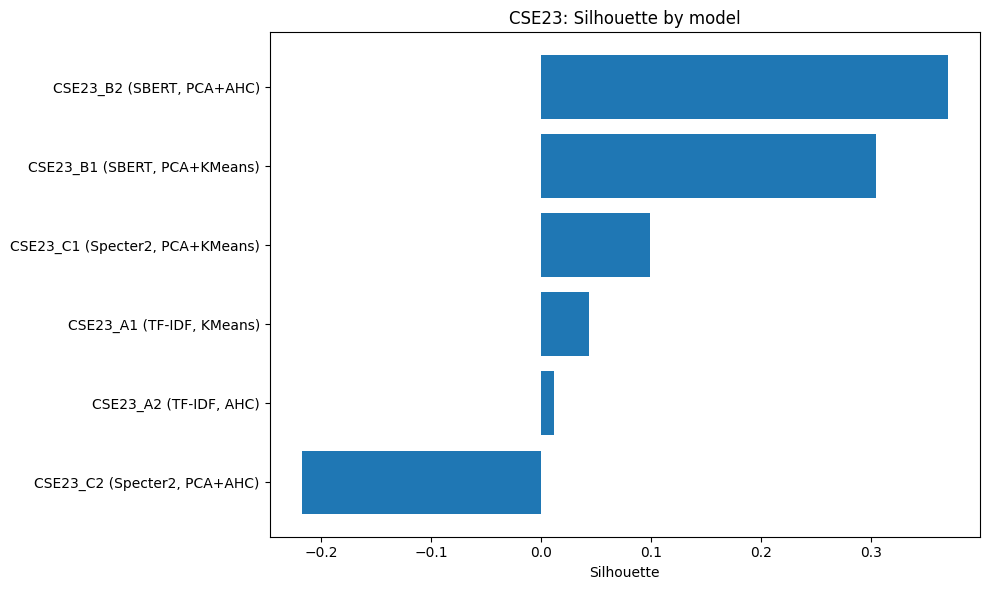

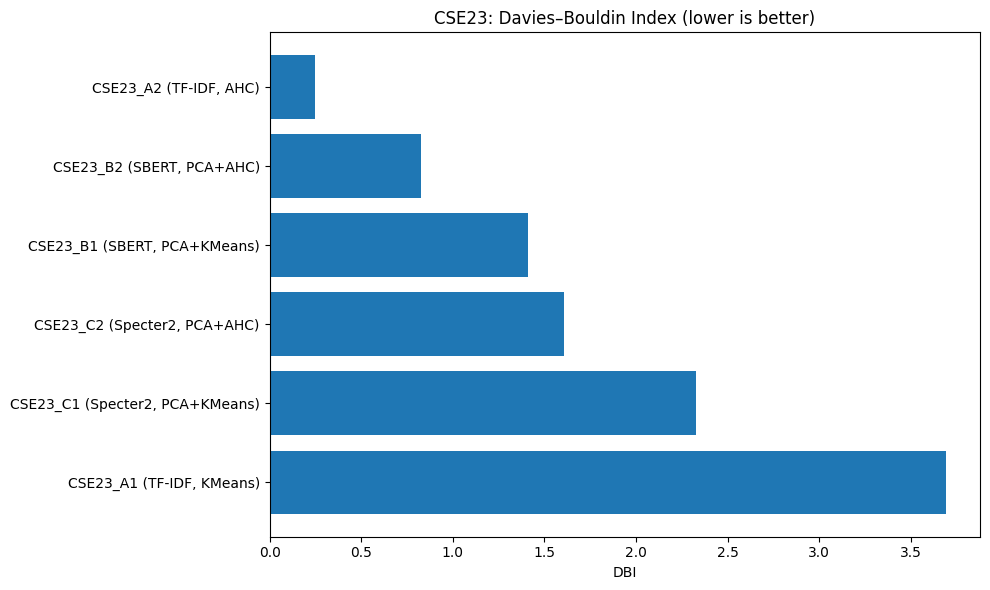

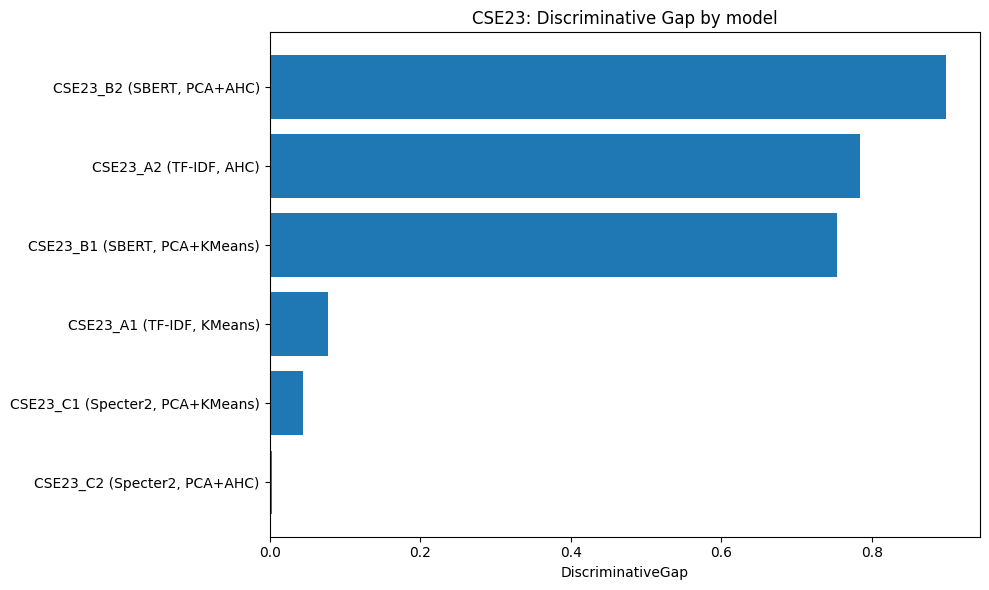

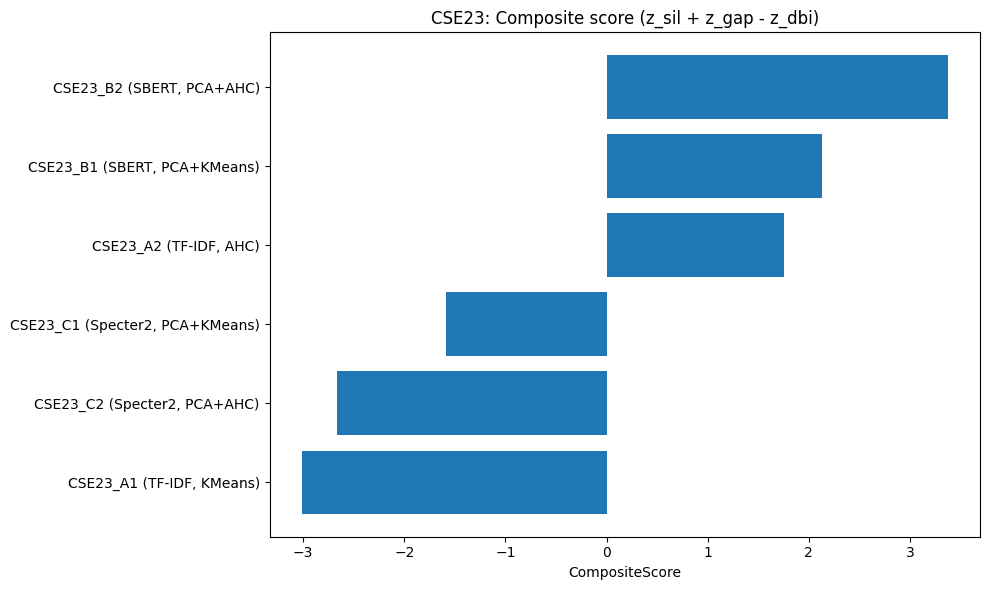

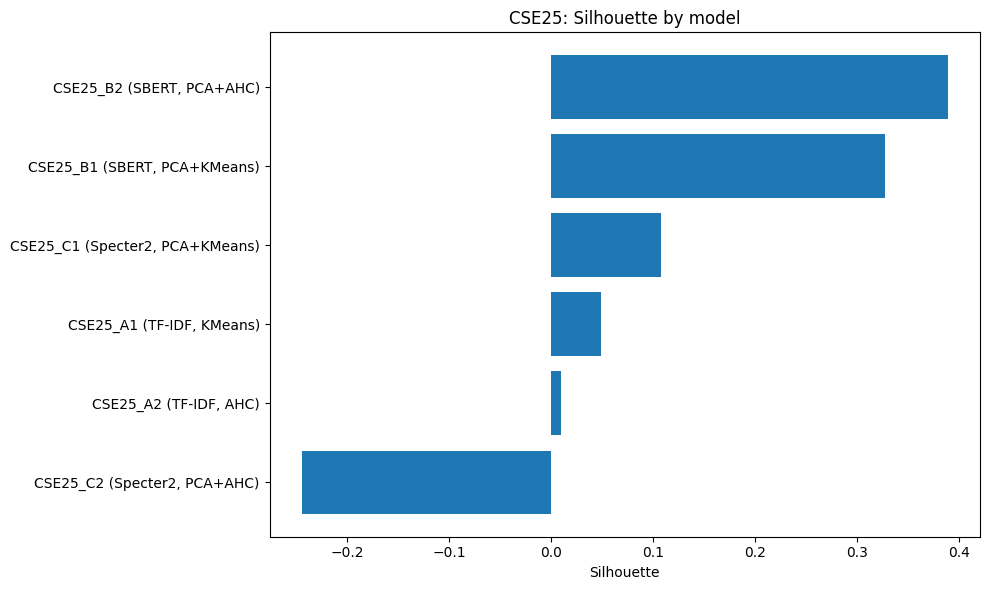

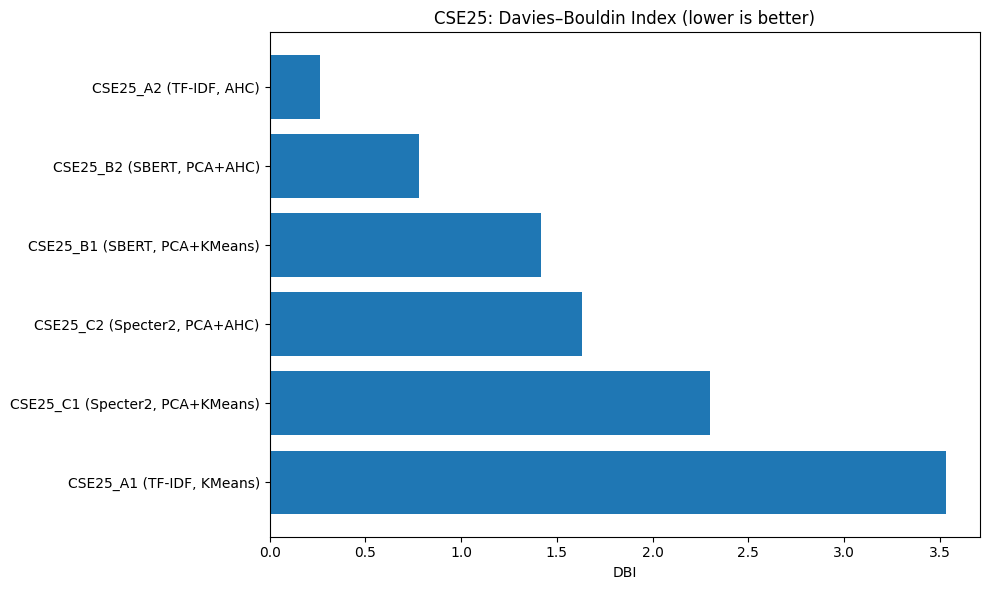

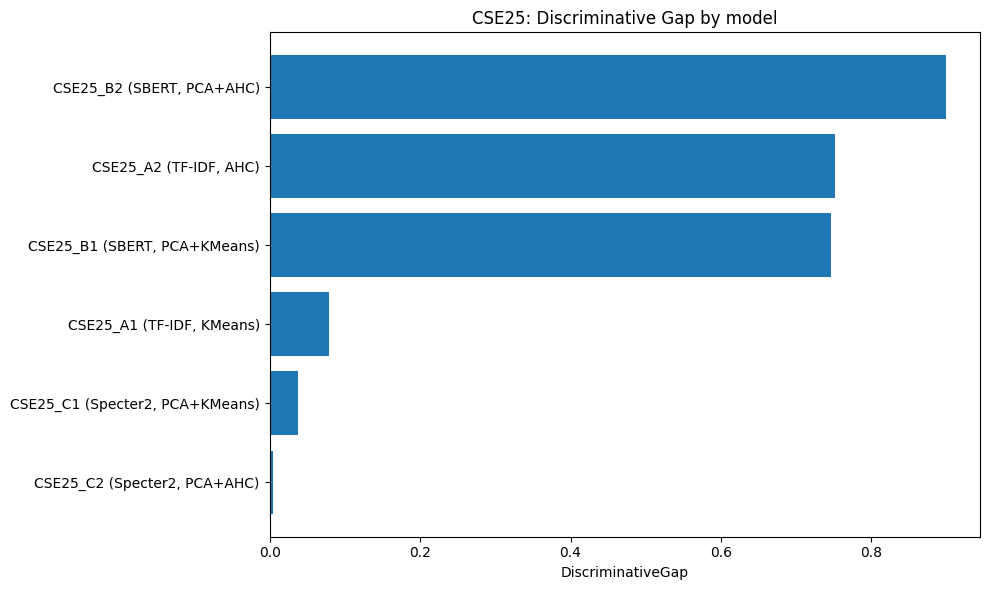

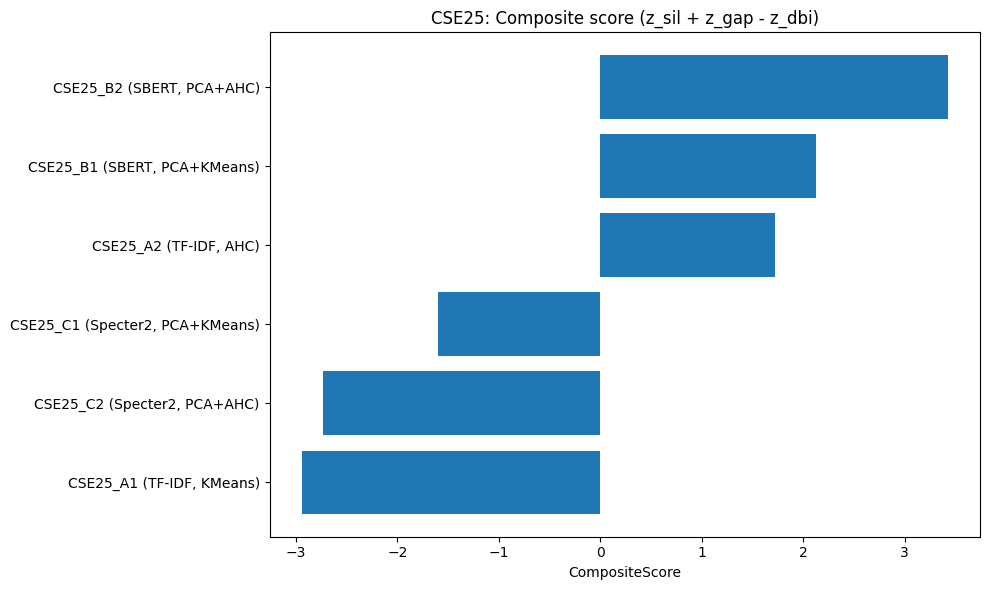

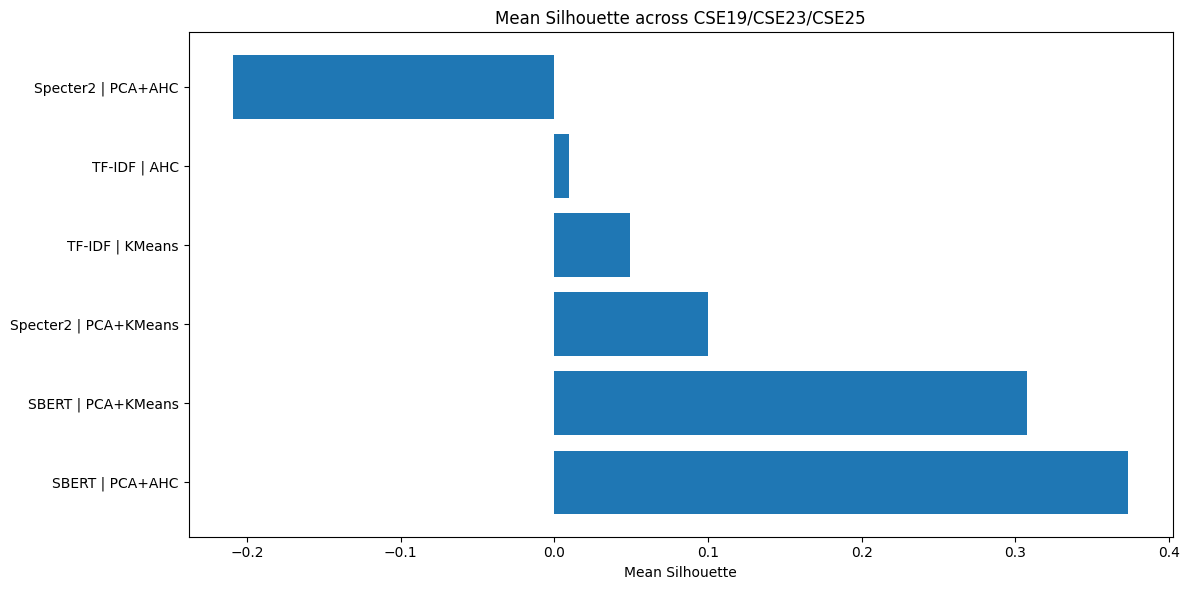

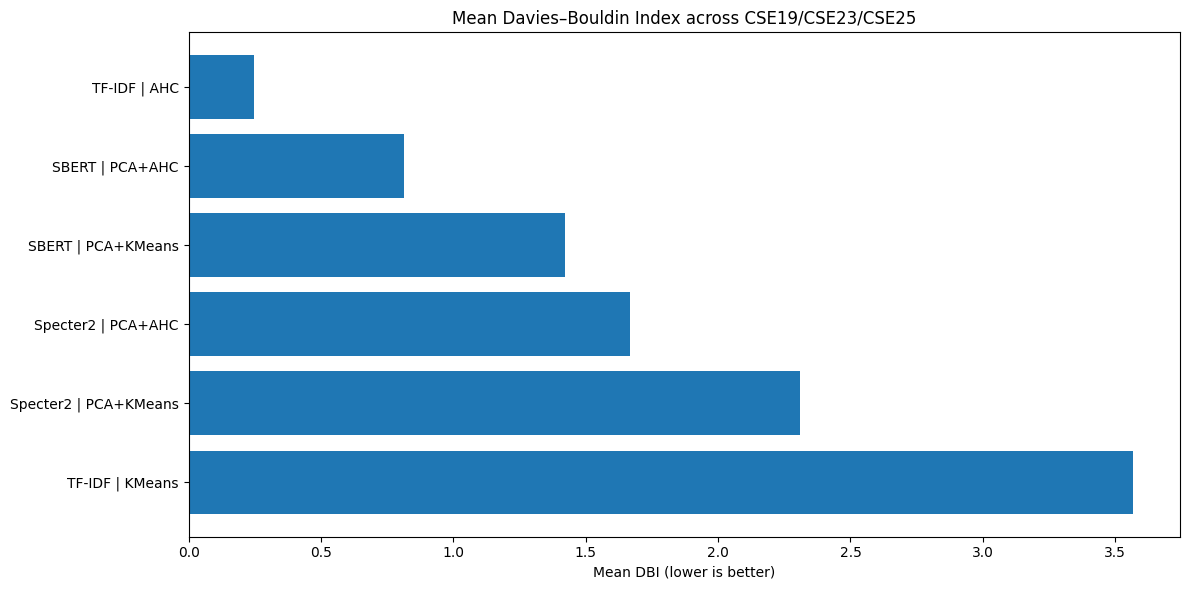

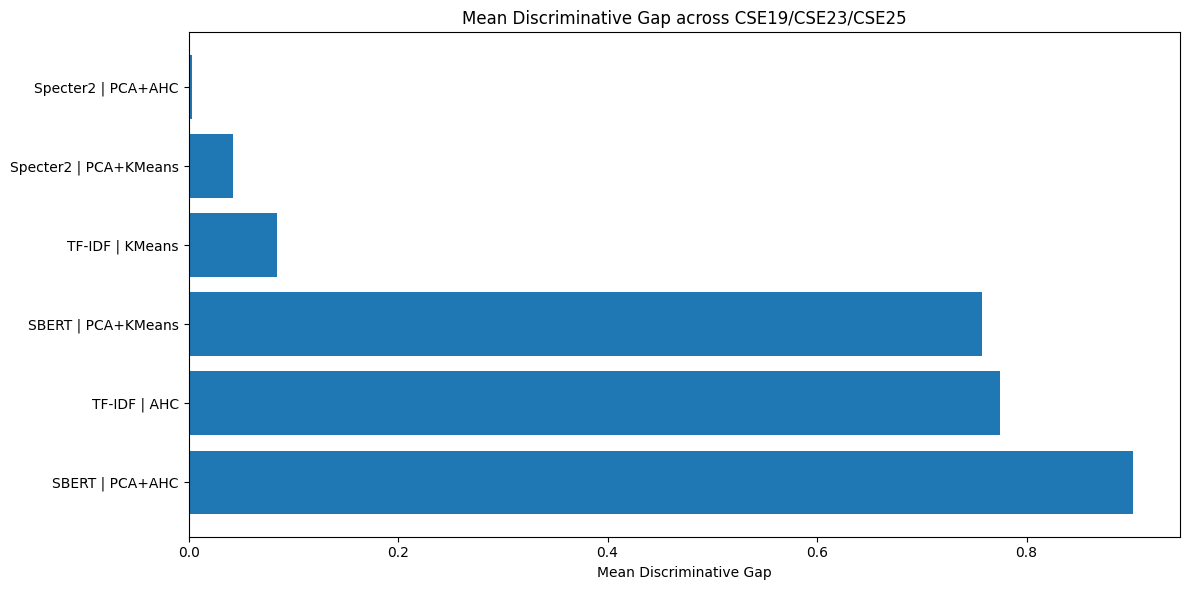

In [39]:
# Canonicalise column names
raw = raw.rename(
    columns={
        "Model Num.": "ModelNum",
        "Model Name": "ModelName",
        "Params": "Params",
        "Clusters Counts": "ClusterCount",
        "Discriminative Gap": "DiscriminativeGap",
        "Avg. Same-Cluster-Sim": "AvgSameClusterSim",
        "Avg. Diff-Cluster-Sim": "AvgDiffClusterSim",
        "Silhouette Score": "Silhouette",
        "Davies-Bouldin Index": "DBI",
    }
)

# Parse conference label from ModelNum (e.g., "CSE25_A1")
raw["Conference"] = raw["ModelNum"].str.extract(r"(CSE\d{2})")

# Derive embedding and algorithm
def parse_embedding(model_name: str) -> str:
    if not isinstance(model_name, str):
        return "Unknown"
    parts = [p.strip() for p in model_name.split("+")]
    return parts[0].strip() if parts else "Unknown"

def parse_algorithm(model_name: str) -> str:
    if not isinstance(model_name, str):
        return "Unknown"
    # Everything after the first '+' is the algorithm description
    parts = [p.strip() for p in model_name.split("+")]
    algo = "+".join(parts[1:]).strip() if len(parts) > 1 else ""
    # Normalise common names
    algo = algo.replace("Hierarchical Clusters", "AHC")
    algo = algo.replace("PCA +", "PCA+")
    # Tidy repeated spaces
    algo = " ".join(algo.split())
    if not algo:
        algo = "Unknown"
    return algo

raw["Embedding"] = raw["ModelName"].apply(parse_embedding)
raw["Algorithm"] = raw["ModelName"].apply(parse_algorithm)
raw["IsOptimal"] = raw["ModelName"].str.contains("optimal", case=False, na=False)

# Remove exact duplicate rows; then deduplicate by (Conference, ModelNum) keeping the last
raw = raw.drop_duplicates()
raw = raw.sort_values(["Conference", "ModelNum"]).drop_duplicates(
    subset=["Conference", "ModelNum"], keep="last"
)

# Compute a composite score per conference (higher is better):
# z-score(Silhouette) + z-score(DiscriminativeGap) + z-score(-DBI)
def zscore(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1)

summary_list = []
for conf, g in raw.groupby("Conference"):
    g = g.copy()
    g["z_sil"] = zscore(g["Silhouette"])
    g["z_gap"] = zscore(g["DiscriminativeGap"])
    g["z_nDBI"] = zscore(-g["DBI"])  # lower DBI is better
    g["CompositeScore"] = g[["z_sil", "z_gap", "z_nDBI"]].sum(axis=1)
    g = g.sort_values("CompositeScore", ascending=False)
    g["Rank"] = np.arange(1, len(g) + 1)
    summary_list.append(g)

summary = pd.concat(summary_list, ignore_index=True)

# Save combined raw and summary to files
combined_csv = "clustering_results_combined.csv"
summary_csv = "clustering_results_summary.csv"
excel_path = "clustering_results_summary.xlsx"

raw.to_csv(combined_csv, index=False)
summary.to_csv(summary_csv, index=False)
with pd.ExcelWriter(excel_path) as writer:
    raw.to_excel(writer, index=False, sheet_name="Raw")
    summary.to_excel(writer, index=False, sheet_name="Summary")

# Display the main combined table to the user
display("Clustering results (combined)", raw)

# --- Plotting helpers ---
PLOTS = []

def plot_bar_by_metric(df, metric, title, filename, ascending=False):
    # Sort for readability
    d = df.sort_values(metric, ascending=ascending)
    labels = d["ModelNum"] + " (" + d["Embedding"] + ", " + d["Algorithm"] + ")"
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels, d[metric].values)
    ax.set_xlabel(metric)
    ax.set_title(title)
    plt.tight_layout()

# Per-conference charts
for conf, g in summary.groupby("Conference"):
    # Silhouette (higher better)
    plot_bar_by_metric(
        g,
        "Silhouette",
        f"{conf}: Silhouette by model",
        f"{conf}_silhouette_by_model.png",
        ascending=True,  # small at bottom, large at top
    )
    # DBI (lower better)
    plot_bar_by_metric(
        g,
        "DBI",
        f"{conf}: Davies–Bouldin Index (lower is better)",
        f"{conf}_dbi_by_model.png",
        ascending=False,  # show best at top (lowest DBI)
    )
    # Discriminative Gap (higher better)
    plot_bar_by_metric(
        g,
        "DiscriminativeGap",
        f"{conf}: Discriminative Gap by model",
        f"{conf}_discriminative_gap_by_model.png",
        ascending=True,
    )
    # Composite score
    plot_bar_by_metric(
        g,
        "CompositeScore",
        f"{conf}: Composite score (z_sil + z_gap - z_dbi)",
        f"{conf}_composite_score_by_model.png",
        ascending=True,
    )

# Cross-conference means by (Embedding, Algorithm) for key metrics
agg = (
    raw.groupby(["Embedding", "Algorithm"])
    .agg(
        mean_sil=("Silhouette", "mean"),
        mean_dbi=("DBI", "mean"),
        mean_gap=("DiscriminativeGap", "mean"),
        count=("ModelNum", "count"),
    )
    .reset_index()
)

# Save the aggregate table
agg_csv =  "aggregate_by_method.csv"
agg.to_csv(agg_csv, index=False)
display("Aggregate metrics by (Embedding, Algorithm)", agg)

def plot_agg_bar(metric, ylabel, filename, title_suffix):
    d = agg.sort_values(metric, ascending=False).copy()
    d["Label"] = d["Embedding"] + " | " + d["Algorithm"]
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(d["Label"], d[metric].values)
    ax.set_xlabel(ylabel)
    ax.set_title(f"Mean {title_suffix} across CSE19/CSE23/CSE25")
    plt.tight_layout()

plot_agg_bar("mean_sil", "Mean Silhouette", "agg_mean_silhouette.png", "Silhouette")
# For DBI, lower is better; we still plot the mean DBI
plot_agg_bar("mean_dbi", "Mean DBI (lower is better)", "agg_mean_dbi.png", "Davies–Bouldin Index")
plot_agg_bar("mean_gap", "Mean Discriminative Gap", "agg_mean_gap.png", "Discriminative Gap")

# Provide a list of generated artefacts for the user
{
    "combined_csv": str(combined_csv),
    "summary_csv": str(summary_csv),
    "excel_path": str(excel_path),
    "aggregate_csv": str(agg_csv),
    "plots": [str(p) for p in PLOTS],
}